# 분위수 회귀 (Quantile Regression)


--------

## 지정학적 위기 시 비트코인은 디지털 금인가?
### 캡스톤디자인 | 팀명: 분석많이된다

---

## 분석 목적

주식 시장이 폭락하는 극단적 하락 구간에서 BTC가 반대 방향으로 움직이는지 검증해요.

Safe-Haven의 핵심 조건: **주가가 떨어질 때 BTC는 올라가야** 해요.

## 왜 분위수 회귀인가?

일반 OLS 회귀는 평균적 관계만 봐요. 하지만 안전자산 여부는 **위기 상황(하위 5~10% 극단 구간)**에서만 의미 있어요.

```
OLS     : 전체 수익률 분포의 평균 관계 → 위기 시 반응을 놓침
분위수  : τ=0.05, 0.10 구간만 집중 분석 → 위기 시 반응 포착
```

## 모델

```
Q_τ(BTC_t) = α_τ + β_τ·SP500_t + γ_τ·GPR_custom_t + ε_t

τ = 0.05 : SP500 하위  5% (극단 하락)
τ = 0.10 : SP500 하위 10% (강한 하락)
τ = 0.50 : 중앙값 (평상시 비교용)

Safe-Haven 조건:
  β_τ < 0  (τ=0.05, 0.10에서)  → 주가 폭락 시 BTC는 반대로 움직임
  p < 0.05 → 통계적으로 유의
```



## 필요 파일

```
master_data.csv
```

### 모델 참조 논문
Koenker & Bassett (1978) “Regression Quantiles” (Econometrica)   
- 분위수 회귀의 원조 논문으로, τ‑분위수를 최소화하는 식 
minβ∑ρτ(Yt−Xt⊤β)min β ∑ρ τ(Y t −X t⊤ β)를 제시함

**Koenker (2005) “Quantile Regression” (Cambridge UP)**
- 선형 분위수 회귀 Qτ(Y∣X)=X⊤βτQ τ​ (Y∣X)=X ⊤ β τ를 교과서적으로 정의
- 특히 현재 수식은 이 구조의 변수를 재정의한 형태

1) 기존 모델
2) 상호작용항 추가 모델
3) 각 모델에 해당하는 (Robustness Check) 수행

### 1. HAC (Newey-West) 논문
1. 원조 논문명 - Newey, W. K., & West, K. D. (1987). "A Simple, Positive Semidefinite, Heteroskedasticity and Autocorrelation Consistent Covariance Matrix." Econometrica, 55, 703–708
- 링크 : https://www.mathworks.com/help/econ/hac.html

2. Bandwidth 자동 선택 논문 -  bw = int(4*(n/100)^(2/9))
- 논문명: Newey, W. K., & West, K. D. (1994). "Automatic Lag Selection in Covariance Matrix Estimation." The Review of Economic Studies, 61(4), 631–653
- 링크 : https://academic.oup.com/restud/article-abstract/61/4/631/1590368?login=false

3. 금융 시계열에서 HAC 사용 정당성
- 논문명 : Newey and West (1987) introduced heteroskedasticity and autocorrelation consistent (HAC) covariance matrix estimator for time series, which allows serial correlations. In the presence of serial and cross-sectional correlations, the conventional standard errors may be biased.
- 링크 : https://www.sciencedirect.com/science/article/abs/pii/S0304407620303341

### 2. Block Bootstrap 논문
1 . Stationary Block Bootstrap 원조 논문
- 논문명 : Politis, D. N., & Romano, J. P. (1994). "The Stationary Bootstrap." Journal of the American Statistical Association, 89(428), 1303–1313. DOI: 10.1080/01621459.1994.10476870
- 링크 : https://www.tandfonline.com/doi/abs/10.1080/01621459.1994.10476870
  
2. Block Bootstrap GARCH 적용 근거
- 논문명 : Stationary Bootstrap Prediction Intervals for GARCH(p,q)
January 2013Communications for Statistical Applications and Methods 20(1)
- 링크 : https://www.researchgate.net/publication/264104997_Stationary_Bootstrap_Prediction_Intervals_for_GARCHpq
   
### Safe-Haven 판정 기준 원조 
- 논문명 : Baur, D. G., & Lucey, B. M. (2010). "Is Gold a Hedge or a Safe Haven? An Analysis of Stocks, Bonds and Gold." Financial Review, 45(2), 217–229.
- 링크 : https://onlinelibrary.wiley.com/doi/abs/10.1111/j.1540-6288.2010.00244.x


---
## Step 0. 라이브러리

In [1]:
!pip install pandas numpy matplotlib scipy statsmodels --quiet

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from statsmodels.regression.quantile_regression import QuantReg
from scipy import stats
import warnings, os, platform
warnings.filterwarnings('ignore')

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 130

EVENT_DATES = {
    'hormuz_crisis'          : '2019-06-13',
    'soleimani_assassination': '2020-01-03',
    'russia_ukraine_war': '2022-02-24',
    'israel_hamas_war'           : '2023-10-07',
    'israel_iran'            : '2024-04-01',
    'us_israel_iran'         : '2026-02-28',
}
EVENT_LABELS = {
    'hormuz_crisis'          : '호르무즈 위기',
    'soleimani_assassination': '솔레이마니 암살',
    'russia_ukraine_war': '러-우 전쟁',
    'israel_hamas_war'           : '이스라엘-하마스',
    'israel_iran'            : '이스라엘-이란 충돌',
    'us_israel_iran'         : '이란 전쟁',
}

# 분석할 분위수 - 분쉬수 0.01, 0.05, 0.20 추가
TAUS = [0.01, 0.025, 0.05, 0.10, 0.20, 0.25, 0.50, 0.75, 0.90, 0.95]
# Safe-Haven 판단 핵심 분위수
CORE_TAUS = [0.05, 0.10, 0.50]

print('✅ 환경 설정 완료')
print(f'   분석 분위수: {TAUS}')

# ── 결과 출력 디렉토리 (표준화) ──
RESULTS_DIR = '../../../Edit_mj/results'  # 노트북 기준 상대경로
os.makedirs(RESULTS_DIR, exist_ok=True)


✅ 환경 설정 완료
   분석 분위수: [0.01, 0.025, 0.05, 0.1, 0.2, 0.25, 0.5, 0.75, 0.9, 0.95]


---
## Step 1. master_data.csv 로드

In [3]:
if not os.path.exists('master_data.csv'):
    raise FileNotFoundError('master_data.csv 없음')

master = pd.read_csv('master_data.csv')
master['date'] = pd.to_datetime(master['date'])

for col in ['BTC','Gold','TLT','DXY','SP500','NASDAQ',
            'GPR_custom','VIX','fear_greed_lag1']:
    if col in master.columns:
        master[col] = pd.to_numeric(master[col], errors='coerce')

print(f'✅ master_data: {len(master)}행')
print(f'   기간: {master["date"].min().date()} ~ {master["date"].max().date()}')
print(f'\n이벤트별 거래일:')
print(master.groupby('event_name')['date'].count().to_string())
print(f'\n결측치:')
key_cols = ['BTC','SP500','GPR_custom']
print(master[key_cols].isnull().sum().to_string())

✅ master_data: 1827행
   기간: 2019-01-02 ~ 2026-04-30

이벤트별 거래일:
event_name
hormuz_crisis              182
israel_hamas_war           260
israel_iran                299
russia_ukraine_war         475
soleimani_assassination    339
us_israel_iran             272

결측치:
BTC           0
SP500         0
GPR_custom    0


---
## Step 2. 분석 데이터 준비

---
**해당 코드 동작 정리**

1. 결측치 제거 : BTC, SP500, GPR_custom, Gold 데이터가 동시에 존재하는 날짜만 남김
2. Z-score 표준화 (_z 컬럼 생성)
3. 자산별 실제 수익률 분포 확인 (quantile(TAUS)) : TAUS에 기재된 해당 분위수의 실제 수익률 값 출력

---

**TAUS를 쉽게 정리**
- $\tau$ 대입 값으로, $\tau = 0.05$ : 전체 100일 중 수익률(%)이 나쁜 순서로 5등 의미 

In [4]:
key_cols = ['BTC', 'SP500', 'GPR_custom', 'Gold']
data_all = master.dropna(subset=key_cols).copy()

# Z-score 표준화 (전체 기준) - Gold 추가
for col in ['SP500', 'GPR_custom', 'VIX', 'Gold']:
    if col in data_all.columns:
        mu, sig = data_all[col].mean(), data_all[col].std()
        if sig > 0:
            data_all[f'{col}_z'] = (data_all[col] - mu) / sig
        else:
            data_all[f'{col}_z'] = 0

print(f'전체 분석 데이터: {len(data_all)}행')

# 주요 자산별 수익률 분위수 확인
assets = ['BTC', 'SP500', 'Gold']

for asset in assets:
    print(f'\n{asset} 수익률 분위수:')
    print(data_all[asset].quantile(TAUS).round(4))

for asset in assets:
    print(f'\n{asset} 수익률 분위수 (% 버전):')
    print((data_all[asset] * 100).quantile(TAUS).round(4))

전체 분석 데이터: 1827행

BTC 수익률 분위수:
0.010   -0.1092
0.025   -0.0737
0.050   -0.0570
0.100   -0.0367
0.200   -0.0208
0.250   -0.0160
0.500    0.0009
0.750    0.0197
0.900    0.0437
0.950    0.0636
Name: BTC, dtype: float64

SP500 수익률 분위수:
0.010   -0.0350
0.025   -0.0253
0.050   -0.0177
0.100   -0.0119
0.200   -0.0063
0.250   -0.0044
0.500    0.0010
0.750    0.0067
0.900    0.0122
0.950    0.0165
Name: SP500, dtype: float64

Gold 수익률 분위수:
0.010   -0.0295
0.025   -0.0233
0.050   -0.0172
0.100   -0.0117
0.200   -0.0059
0.250   -0.0043
0.500    0.0010
0.750    0.0065
0.900    0.0126
0.950    0.0173
Name: Gold, dtype: float64

BTC 수익률 분위수 (% 버전):
0.010   -10.9194
0.025    -7.3733
0.050    -5.6969
0.100    -3.6690
0.200    -2.0833
0.250    -1.5995
0.500     0.0920
0.750     1.9677
0.900     4.3707
0.950     6.3640
Name: BTC, dtype: float64

SP500 수익률 분위수 (% 버전):
0.010   -3.5036
0.025   -2.5266
0.050   -1.7704
0.100   -1.1934
0.200   -0.6324
0.250   -0.4420
0.500    0.0969
0.750    0.6693
0.900    

---
## Step 3. 분위수 회귀 — 전체 이벤트 합산


----

### 개인 주관 포함 코드

1.  **Safe-Haven의 정의** : $\beta < 0$이 아니라, 중앙값($\tau=0.5$)의 $\beta$보다 위기 시($\tau \le 0.1$)의 $\beta$가 더 낮을 때
    - 이때 $\beta$의 정의 : 독립변수(['SP500_z','GPR_custom_z'] or ['Gold_z','GPR_custom_z'])가 1단위 변할 때, 종속변수(비트코인)가 얼마나 변하는지를 나타내는 기울기
    - $\beta > 0$ (양수) : 독립변수가 오를 때 비트코인도 오르고, 내릴 때 같이 내림
    - $\beta < 0$ (음수) : 독립변수가 내릴 때 비트코인은 오르고, 오를 때 반대로 내림
    - $\beta = 0$ (제로) : 독립변수와의 관계 없음



2.  **현 코드의 안전 자산(Safe-Haven)** : 평소는 모르겠으나, 위기 상황일 때 안전자산처럼 행동하는가? 의 기준
    - 평소를 기준 : $\tau=0.5$의 $\beta$
        -> 비트코인도 주식과 같이 유동성의 영향을 받기 때문에 주식과 함께 오르내리는 경향($\beta > 0$)이 강할 수 있음
    - 위기 시의 모습 : $\tau \le 0.1$의 $\beta$ 로, 시장이 하위 10% 이내로 폭락을 위기 상황으로 지정
        -> 이때 비트코인이 진짜 안전자산이라면, S&P500과 $\beta$ = 0 이 되거나, 반대되는 움직임을 보여야 함

    - 두 개의 기준을 갖고 비교하는 이유(=중앙값보다 위기 시의 베타가 더 낮아야 한다) : 평소에 주식과 0.5만큼 같이 움직였다면, 위기 상황 때 반대로 움직임(베타가 평소보다 낮아진다면)을 보여야 안전 자산 취급이 가능한 것

3. **분위수 선택 (TAUS)**
- 어디서부터 위기자산으로 취급할건지 자체가 주관적 선택
  
4. **유의수준(p-value)의 기준**
   - $p < 0.05$ (): 95% 신뢰 수준이 가장 보편적이기 때문에, 유의한 결과로 사용
   - 0.10(△)은 '잠재적 경향성'으로 사용




---

### 현재 코드 정리본

| 항목 | 내용 |
|---|---|
| MODELS 딕셔너리 |  SP500+GPR / Gold+GPR 두 모델 한 곳에서 관리 |
| run_and_print_both_models()  | 데이터셋 하나에 두 모델 나란히 출력 |
| Step3/4 공통 함수 사용  | 전체합산·이벤트별 동일 로직 재사용 |
| 최종 비교표  | 전쟁별 × 두 모델 τ=0.05 결과 한눈에 비교 |

1. 이중 모델링 작업
   - 주식 동조화 확인 모델 : $$Q_{\tau}(\text{BTC} | X) = \alpha_{\tau} + \beta_{1,\tau}(\text{SP500}_z) + \beta_{2,\tau}(\text{GPR}_z)$$
   - 안전자산 동조화 확인 모델 : $$Q_{\tau}(\text{BTC} | X) = \alpha_{\tau} + \beta_{1,\tau}(\text{Gold}_z) + \beta_{2,\tau}(\text{GPR}_z)$$
     
2. HAC(Newey-West) 표준오차 도입
    - 기존 vcov='robust'보다 나아가 시차(Lag)를 고려해서 표준오차를 교정함  
      -> 이분산성/자기상관 무시 시 표준오차가 과소추정 → p-value가 과소평가(너무 작게 나옴) → 실제로 유의하지 않은데 유의하다고 판단하는 제1종 오류를 방지
    - 이거로, 시계열 노이즈인 이분산성(시장의 변동성이 커질 때, 오차항의 범위도 같이 넓어지는 현상  
      -> 잔차의 분산이 독립변수 값에 상관없이 일정해야 한다는 회귀 분석의 기본 가정이 깨진 것) + 자기상관(어제의 변동이 오늘에 영향)을 제거

3. Block Bootstrap
   : 21일치(1개월)씩 block 단위로 묶어서 재샘플링하여, 시계열 흐름을 보존.
   - p-value와 HAC 결과를 교차 검증(Cross-check)하여 분석의 강건성(Robustness)을 확보
  
4. 6개 전쟁 데이터를 일일이 자를 필요 없이, event_name을 기준으로 루프를 돌며 이벤트별 개별 특성을 추출


---

### 하이퍼파라미터 수정 가능 파트

1. min_n: 필요한 최소 데이터 수를 30개로 지정(총 데이터 1824개기 때문에 간단한 조건 정도로 이해)
   - 이때 로직 정리 : 전체 데이터 중에 TAUS를 통해 정한 분위수만큼 해당하는 하위 데이터만 추출
   - τ=0.05는 전체 분포에서 하위 5% 구간의 BTC 수익률을 설명하는 회귀선을 추정함  
    → 실제로 활용되는 데이터 수 = 전체 n × 0.05  
    → n=1824이면 유효 데이터 약 91개

2. HAC 시차 결정 계수 (bw 계산식)
- `bw = max(1, int(4 * (n / 100)  (2/9)))`
- bw는 오늘 발생한 오차가 과거 며칠 전의 오차와 연결되어 있는지 그 범위를 설정하는 값
- `int(4 * (n / 100)  (2/9))` : 데이터 개수에 따른 최적의 시차 찾는 것으로 데이터가 많아질수록 과거를 더 봐야한다는 논리
  -> 그래서 우리 데이터 양에 맞게 범위를 자동적으로 정해주는 수식
    
3. 부트스트랩 반복 횟수 및 블록 크기 (B, block_size)
   - B를 키울수록: p-value가 더 안정적으로 수렴하지만 계산 시간이 오래 걸림
   - block_size를 키울수록: 더 긴 기간의 시장 흐름을 보존하지만, 블록 수가 적어져서 샘플링의 다양성이 떨어질 수 있음

In [5]:
import numpy as np
from statsmodels.regression.quantile_regression import QuantReg
from statsmodels.tools import add_constant
from scipy.stats import t as t_dist

# ══════════════════════════════════════════════════════
# 모델 정의
# ══════════════════════════════════════════════════════
MODELS = {
    'SP500+GPR': ['SP500_z', 'GPR_custom_z'],  # 주식 + 전쟁지수
    'Gold+GPR' : ['Gold_z',  'GPR_custom_z'],  # 금   + 전쟁지수
}

# ══════════════════════════════════════════════════════
# HAC 함수 (x_cols를 외부에서 받도록 수정)
# ══════════════════════════════════════════════════════
def run_quantreg_hac(data, tau, y_col='BTC', x_cols=None, min_n=30):
    if x_cols is None:
        x_cols = ['SP500_z', 'GPR_custom_z']

    available_x = [c for c in x_cols if c in data.columns]
    df = data[[y_col] + available_x].dropna()
    if len(df) < min_n:
        return None

    effective_n = len(df) * tau
    if effective_n < 5:
        print(f"  ⚠️  τ={tau} 유효 데이터 {effective_n:.1f}개")

    y = df[y_col].values
    X = add_constant(df[available_x].values)
    n = len(df)
    bw = max(1, int(4 * (n / 100) ** (2/9)))

    try:
        model  = QuantReg(y, X)
        res    = model.fit(q=tau, max_iter=2000, p_tol=1e-05, vcov='iid')
        params = res.params
        resid  = y - X @ params
        n, k   = X.shape

        S       = np.zeros((k, k))
        Gamma_0 = (resid[:, None] * X).T @ (resid[:, None] * X) / n
        S      += Gamma_0

        for lag in range(1, bw + 1):
            weight  = 1 - lag / (bw + 1)
            Gamma_l = (resid[lag:, None] * X[lag:]).T \
                    @ (resid[:-lag, None] * X[:-lag]) / n
            S += weight * (Gamma_l + Gamma_l.T)

        XX_inv = np.linalg.inv(X.T @ X / n)
        V_hac  = XX_inv @ S @ XX_inv / n
        se_hac = np.sqrt(np.diag(V_hac))
        t_stat = params / se_hac
        pvals  = 2 * (1 - t_dist.cdf(np.abs(t_stat), df=n - k))

        return {
            'tau'     : tau,
            'n'       : n,
            'eff_n'   : effective_n,
            'bw'      : bw,
            'params'  : params,
            'se'      : se_hac,
            'pvalues' : pvals,
            'conf_int': np.column_stack([params - 1.96 * se_hac,
                                         params + 1.96 * se_hac]),
            'x_cols'  : ['const'] + available_x,
            'result'  : res,
            'method'  : f'HAC(bw={bw})',
        }
    except Exception as e:
        print(f'  ⚠️ τ={tau} HAC 오류: {e}')
        return None


# ══════════════════════════════════════════════════════
# Safe-Haven 판정
# ══════════════════════════════════════════════════════
def judge_safe_haven(b, pb, b_median, tau):
    if tau > 0.10:
        return '—'
    if pd.isna(pb) or pd.isna(b):
        return '⚪ 판정불가'
    if pb < 0.05 and b < 0:
        if b_median is not None and b < b_median:
            return '✅ Safe Haven(위기 강화)'
        elif b_median is not None and b >= b_median:
            return '⚠️ 항상 반대자산 의심'
        return '✅ Safe Haven'
    elif pb < 0.05 and b > 0:
        return '❌ Risky Asset'
    elif pb < 0.10 and b < 0:
        return '🔵 Weak SH(10%)'
    return '⚪ 비유의'


# ══════════════════════════════════════════════════════
# 단일 데이터셋 × 두 모델 출력 함수
# ══════════════════════════════════════════════════════
def run_and_print_both_models(data, label='전체 합산'):
    """
    SP500+GPR / Gold+GPR 두 모델을 나란히 출력
    """
    print(f'\n{"═"*90}')
    print(f'  📌 {label}')
    print(f'{"═"*90}')

    # 결과 저장
    model_results = {}

    for model_name, x_cols in MODELS.items():

        print(f'\n  ── {model_name} ──────────────────────────────────────')

        # 주요 변수명 (SP500_z or Gold_z)
        main_var = x_cols[0]

        # τ=0.50 중앙값 β 사전 계산
        res_med     = run_quantreg_hac(data, 0.50, x_cols=x_cols)
        b_median    = None
        if res_med and main_var in res_med['x_cols']:
            idx      = res_med['x_cols'].index(main_var)
            b_median = res_med['params'][idx]

        print(f'  {"τ":>6} {"n":>5} {"유효n":>6} {"BW":>4} '
              f'{f"β({main_var})":>14} {"p(β)":>8} '
              f'{"γ(GPR)":>12} {"p(γ)":>8}  {"판정"}')
        print('  ' + '-' * 88)

        tau_results = {}

        for tau in TAUS:
            res = run_quantreg_hac(data, tau, x_cols=x_cols)
            tau_results[tau] = res

            if res is None:
                print(f'  {tau:>6.2f}  데이터 부족')
                continue

            x_c   = res['x_cols']
            m_i   = x_c.index(main_var)          if main_var      in x_c else None
            gpr_i = x_c.index('GPR_custom_z')    if 'GPR_custom_z' in x_c else None

            b   = res['params'][m_i]   if m_i   is not None else np.nan
            pb  = res['pvalues'][m_i]  if m_i   is not None else np.nan
            g   = res['params'][gpr_i] if gpr_i is not None else np.nan
            pg  = res['pvalues'][gpr_i] if gpr_i is not None else np.nan

            sig_b = '✅' if pb < 0.05 else '△' if pb < 0.10 else '—'
            sig_g = '✅' if pg < 0.05 else '△' if pg < 0.10 else '—'

            verdict = judge_safe_haven(
                b, pb,
                b_median if tau <= 0.10 else None,
                tau
            )

            print(f'  {tau:>6.2f} {res["n"]:>5} {res["eff_n"]:>6.1f} '
                  f'{res["bw"]:>4} '
                  f'{b:>12.5f}{sig_b:>2} {pb:>8.4f} '
                  f'{g:>10.5f}{sig_g:>2} {pg:>8.4f}  {verdict}')

        model_results[model_name] = tau_results

    # ── 두 모델 핵심 비교 요약 ──────────────────────────────
    print(f'\n  {"─"*88}')
    print(f'  ▶ [{label}] 핵심 비교 — τ=0.05, 0.10')
    print(f'  {"─"*88}')
    print(f'  {"모델":<14} {"τ":>6} '
          f'{"β":>12} {"p":>8} {"판정"}')
    print(f'  {"─"*55}')

    for model_name, x_cols in MODELS.items():
        main_var = x_cols[0]
        for tau in [0.05, 0.10]:
            res = model_results[model_name].get(tau)
            if res is None:
                print(f'  {model_name:<14} {tau:>6.2f}  데이터 부족')
                continue
            x_c = res['x_cols']
            m_i = x_c.index(main_var) if main_var in x_c else None
            if m_i is None:
                continue
            b  = res['params'][m_i]
            pb = res['pvalues'][m_i]

            res_med  = model_results[model_name].get(0.50)
            b_med    = None
            if res_med and main_var in res_med['x_cols']:
                b_med = res_med['params'][res_med['x_cols'].index(main_var)]

            verdict = judge_safe_haven(b, pb, b_med, tau)
            sig = '✅' if pb < 0.05 else '△' if pb < 0.10 else '—'
            print(f'  {model_name:<14} {tau:>6.2f} '
                  f'{b:>12.5f}{sig:>2} {pb:>8.4f}  {verdict}')
        print()

    return model_results


# ══════════════════════════════════════════════════════
# Step 3. 전체 합산 실행
# ══════════════════════════════════════════════════════

# 다중공선성 사전 확인
print('▶ 다중공선성 사전 확인')
for model_name, x_cols in MODELS.items():
    existing = [c for c in x_cols if c in data_all.columns]
    if len(existing) >= 2:
        corr = data_all[existing].corr().iloc[0, 1]
        flag = '⚠️ 위험' if abs(corr) > 0.5 else '✅ 이상없음'
        print(f'  [{model_name}] {existing[0]} ↔ {existing[1]}: '
              f'{corr:.3f}  {flag}')

results_all = run_and_print_both_models(data_all, label='전체 합산')


# ══════════════════════════════════════════════════════
# Step 4. 이벤트별 실행
# ══════════════════════════════════════════════════════
results_event = {}

for event, event_label in EVENT_LABELS.items():
    sub   = data_all[data_all['event_name'] == event].copy()
    n_sub = len(sub.dropna(subset=['BTC', 'SP500_z', 'Gold_z', 'GPR_custom_z']))

    if n_sub < 30:
        print(f'\n⚠️  {event_label}: n={n_sub} < 30 → 분석 불가')
        results_event[event] = None
        continue

    results_event[event] = run_and_print_both_models(sub, label=event_label)


# ══════════════════════════════════════════════════════
# 최종 비교표 — 전쟁별 × 모델별
# ══════════════════════════════════════════════════════
print('\n\n' + '═' * 95)
print('  📊 최종 비교표 — 전쟁별 × SP500+GPR / Gold+GPR')
print('═' * 95)
print(f'  {"이벤트":<22} {"n":>5} '
      f'{"SP500 τ=0.05":>14} {"p":>7} '
      f'{"Gold τ=0.05":>13} {"p":>7}  '
      f'{"SP500판정":<22} {"Gold판정"}')
print('  ' + '-' * 100)

for event, event_label in EVENT_LABELS.items():
    ev_res = results_event.get(event)
    n_ev   = len(data_all[data_all['event_name'] == event]
                 .dropna(subset=['BTC', 'SP500_z', 'Gold_z', 'GPR_custom_z']))

    if ev_res is None:
        print(f'  {event_label:<22} {n_ev:>5}  분석 불가')
        continue

    row = {}
    for model_name, x_cols in MODELS.items():
        main_var = x_cols[0]
        res_05   = ev_res.get(model_name, {}).get(0.05)
        res_50   = ev_res.get(model_name, {}).get(0.50)

        if res_05 is None:
            row[model_name] = (np.nan, np.nan, 'N/A')
            continue

        x_c = res_05['x_cols']
        m_i = x_c.index(main_var) if main_var in x_c else None
        if m_i is None:
            row[model_name] = (np.nan, np.nan, 'N/A')
            continue

        b  = res_05['params'][m_i]
        pb = res_05['pvalues'][m_i]

        b_med = None
        if res_50 and main_var in res_50['x_cols']:
            b_med = res_50['params'][res_50['x_cols'].index(main_var)]

        verdict = judge_safe_haven(b, pb, b_med, 0.05)
        row[model_name] = (b, pb, verdict)

    b_sp, p_sp, v_sp = row.get('SP500+GPR', (np.nan, np.nan, 'N/A'))
    b_gd, p_gd, v_gd = row.get('Gold+GPR',  (np.nan, np.nan, 'N/A'))

    b_sp_s = f'{b_sp:.5f}' if pd.notna(b_sp) else '   N/A  '
    p_sp_s = f'{p_sp:.4f}' if pd.notna(p_sp) else '  N/A '
    b_gd_s = f'{b_gd:.5f}' if pd.notna(b_gd) else '   N/A  '
    p_gd_s = f'{p_gd:.4f}' if pd.notna(p_gd) else '  N/A '

    print(f'  {event_label:<22} {n_ev:>5} '
          f'{b_sp_s:>14} {p_sp_s:>7} '
          f'{b_gd_s:>13} {p_gd_s:>7}  '
          f'{v_sp:<22} {v_gd}')

print('\n  ✅=안전자산  🔵=약한경향  ❌=위험자산  ⚪=비유의  ⚠️=항상반대')

▶ 다중공선성 사전 확인
  [SP500+GPR] SP500_z ↔ GPR_custom_z: -0.031  ✅ 이상없음
  [Gold+GPR] Gold_z ↔ GPR_custom_z: 0.013  ✅ 이상없음

══════════════════════════════════════════════════════════════════════════════════════════
  📌 전체 합산
══════════════════════════════════════════════════════════════════════════════════════════

  ── SP500+GPR ──────────────────────────────────────
       τ     n    유효n   BW     β(SP500_z)     p(β)       γ(GPR)     p(γ)  판정
  ----------------------------------------------------------------------------------------
    0.01  1827   18.3    7      0.02552 ✅   0.0000   -0.00037 —   0.9551  ❌ Risky Asset
    0.03  1827   45.7    7      0.02099 ✅   0.0000    0.00090 —   0.8426  ❌ Risky Asset
    0.05  1827   91.4    7      0.01783 ✅   0.0000    0.00125 —   0.7084  ❌ Risky Asset
    0.10  1827  182.7    7      0.01588 ✅   0.0000    0.00062 —   0.8086  ❌ Risky Asset
    0.20  1827  365.4    7      0.01303 ✅   0.0000    0.00079 —   0.6353  —
    0.25  1827  456.8    7      0.01210

    0.01  1827   18.3    7      0.01449 ✅   0.0000   -0.02141 ✅   0.0310  ❌ Risky Asset
    0.03  1827   45.7    7      0.00689 ✅   0.0012   -0.00364 —   0.4876  ❌ Risky Asset
    0.05  1827   91.4    7      0.00598 ✅   0.0005   -0.00088 —   0.8157  ❌ Risky Asset
    0.10  1827  182.7    7      0.00389 ✅   0.0050    0.00024 —   0.9288  ❌ Risky Asset
    0.20  1827  365.4    7      0.00354 ✅   0.0035    0.00072 —   0.6852  —


    0.25  1827  456.8    7      0.00241 ✅   0.0393    0.00029 —   0.8511  —
    0.50  1827  913.5    7      0.00375 ✅   0.0007    0.00060 —   0.5449  —


    0.75  1827 1370.2    7      0.00366 ✅   0.0019    0.00113 —   0.3783  —
    0.90  1827 1644.3    7      0.00166 —   0.2628    0.00182 —   0.4754  —
    0.95  1827 1735.6    7      0.00490 ✅   0.0055    0.00088 —   0.8068  —

  ────────────────────────────────────────────────────────────────────────────────────────
  ▶ [전체 합산] 핵심 비교 — τ=0.05, 0.10
  ────────────────────────────────────────────────────────────────────────────────────────
  모델                  τ            β        p 판정
  ───────────────────────────────────────────────────────
  SP500+GPR        0.05      0.01783 ✅   0.0000  ❌ Risky Asset
  SP500+GPR        0.10      0.01588 ✅   0.0000  ❌ Risky Asset

  Gold+GPR         0.05      0.00598 ✅   0.0005  ❌ Risky Asset
  Gold+GPR         0.10      0.00389 ✅   0.0050  ❌ Risky Asset


══════════════════════════════════════════════════════════════════════════════════════════
  📌 호르무즈 위기
══════════════════════════════════════════════════════════════════════════════════════════


       τ     n    유효n   BW     β(SP500_z)     p(β)       γ(GPR)     p(γ)  판정
  ----------------------------------------------------------------------------------------
  ⚠️  τ=0.01 유효 데이터 1.8개
    0.01   182    1.8    4      0.00443 —   0.7940   -0.06262 △   0.0910  ⚪ 비유의
  ⚠️  τ=0.025 유효 데이터 4.5개
    0.03   182    4.5    4      0.00752 —   0.6387   -0.05545 △   0.0957  ⚪ 비유의
    0.05   182    9.1    4     -0.00109 —   0.9170   -0.01135 —   0.4283  ⚪ 비유의
    0.10   182   18.2    4      0.01172 —   0.2814   -0.01376 —   0.2911  ⚪ 비유의
    0.20   182   36.4    4     -0.00049 —   0.9521   -0.00458 —   0.5517  —
    0.25   182   45.5    4      0.00397 —   0.6231   -0.00015 —   0.9801  —
    0.50   182   91.0    4     -0.00153 —   0.8301    0.00332 —   0.4221  —
    0.75   182  136.5    4     -0.00701 —   0.2939    0.01413 ✅   0.0112  —
    0.90   182  163.8    4     -0.02309 ✅   0.0097    0.02426 ✅   0.0387  —
    0.95   182  172.9    4     -0.02231 ✅   0.0251    0.01470 —   0.2264  —

  ──

...

    0.05   299   15.0    5      0.00315 —   0.5767   -0.00213 —   0.7437  ⚪ 비유의
    0.10   299   29.9    5      0.00372 —   0.4437   -0.00162 —   0.7332  ⚪ 비유의
    0.20   299   59.8    5      0.00372 —   0.3874    0.00198 —   0.5381  —
    0.25   299   74.8    5      0.00577 —   0.1653   -0.00002 —   0.9956  —
    0.50   299  149.5    5      0.00640 △   0.0870    0.00067 —   0.7683  —
    0.75   299  224.2    5      0.00144 —   0.6696   -0.00190 —   0.5479  —
    0.90   299  269.1    5     -0.00151 —   0.6969   -0.00037 —   0.9453  —
    0.95   299  284.1    5     -0.00989 ✅   0.0465   -0.00298 —   0.6641  —

  ────────────────────────────────────────────────────────────────────────────────────────
  ▶ [이스라엘-이란 충돌] 핵심 비교 — τ=0.05, 0.10
  ────────────────────────────────────────────────────────────────────────────────────────
  모델                  τ            β        p 판정
  ───────────────────────────────────────────────────────
  SP500+GPR        0.05      0.02349 ✅   0.0000  ❌ Risky

    0.01   272    2.7    4      0.01129 ✅   0.0394    0.01244 ✅   0.0419  ❌ Risky Asset


    0.03   272    6.8    4      0.01691 ✅   0.0027    0.00849 ✅   0.0486  ❌ Risky Asset
    0.05   272   13.6    4      0.01611 ✅   0.0020    0.00655 △   0.0966  ❌ Risky Asset
    0.10   272   27.2    4      0.01669 ✅   0.0009    0.00504 —   0.1110  ❌ Risky Asset
    0.20   272   54.4    4      0.01464 ✅   0.0004    0.00192 —   0.4598  —


    0.25   272   68.0    4      0.01424 ✅   0.0003    0.00341 △   0.0917  —
    0.50   272  136.0    4      0.01201 ✅   0.0001    0.00259 ✅   0.0353  —
    0.75   272  204.0    4      0.00952 ✅   0.0002    0.00061 —   0.7625  —
    0.90   272  244.8    4      0.00716 ✅   0.0090    0.00316 —   0.4210  —
    0.95   272  258.4    4      0.00660 ✅   0.0309    0.00115 —   0.8139  —

  ── Gold+GPR ──────────────────────────────────────
       τ     n    유효n   BW      β(Gold_z)     p(β)       γ(GPR)     p(γ)  판정
  ----------------------------------------------------------------------------------------
  ⚠️  τ=0.01 유효 데이터 2.7개
    0.01   272    2.7    4     -0.00075 —   0.7427    0.01159 △   0.0807  ⚪ 비유의
    0.03   272    6.8    4      0.00147 —   0.4718    0.00998 △   0.0718  ⚪ 비유의
    0.05   272   13.6    4      0.00103 —   0.5483    0.00626 —   0.1932  ⚪ 비유의
    0.10   272   27.2    4     -0.00133 —   0.3434    0.00159 —   0.6975  ⚪ 비유의
    0.20   272   54.4    4     -0.00046 —   0.6867   

  이란 전쟁                    272        0.01611  0.0020       0.00103  0.5483  ❌ Risky Asset          ⚪ 비유의

  ✅=안전자산  🔵=약한경향  ❌=위험자산  ⚪=비유의  ⚠️=항상반대


---
### 이벤트 합산 버전

**한줄 결론** : 위험 자산(Risky Asset) 판정
1) 모든 위기 구간($\tau=0.01 \sim 0.10$)에서 비트코인은 주식(S&P500) 및 금(Gold) 모델 모두에서 ❌ Risky Asset으로 결론 도출됨
2) 시장 공포로, 하락할 때 비트코인은 오히려 더 세게 같이 무너짐

**3가지 인사이트 정리**
1) 주식과 완전한 동조화(SP500 모델)
   - 시장이 최악일수록($\tau=0.01$) 주식과의 상관계수($\beta$)가 0.025가 가장 높음
   - 평소($\tau=0.50, \beta=0.010$)보다 폭락장일 때의 주식을 따라가는 힘이 2.5배 증가

2) 금과의 역동작(Gold 모델)
   - 금 가격이 오를 때 비트코인도 오르는 것처럼 보이지만($\beta > 0$), 시장이 최악일 때는 금과 같은 방향으로 하락

3) 상대적 동조화 분석
- 분석 결과 비트코인이 금과 함께 움직임. 하지만 주식 시장을 따라가는 힘이 금보다 3배나 더 강함.
   
| 비교 대상 | 분위수(τ) | β 값 (동조화 강도) | 해석 |
|---|---|---|---|
| SP500 모델 | 0.05 | 0.01783 | 주식이 1만큼 빠질 때 비트코인은 이만큼 세게 따라감 | 
| Gold 모델 | 0.05 | 0.00598 | 금이 1만큼 빠질 때 비트코인은 훨씬 살살 따라감 | 

---
### 이벤트별 정리

1) 이벤트 별 판정 정리  

| 분석 대상 (이벤트) | SP500 모델 판정 | Gold 모델 판정 | 종합 결론 및 정체성 | 
|---|---|---|---|
| 🚩 전체 합산 | ❌ Risky Asset | ❌ Risky Asset | 완벽한 위험 자산 (정석적 패턴) | 
| 📌 호르무즈 위기 | ⚪ 비유의 | ❌ Risky Asset | "주식은 무시, 금의 변동성에만 기생" | 
| 📌 솔레이마니 암살 | ❌ Risky Asset | ❌ Risky Asset | 주식·금 가릴 것 없이 동반 폭락 | 
| 📌 러-우 전쟁 | ❌ Risky Asset | ⚪ 비유의 | 주식의 충실한 추종자 (금은 남남) | 
| 📌 이스라엘-하마스 | ❌ Risky Asset | ⚪ 비유의 | 주식의 충실한 추종자 (금은 남남) | 
| 📌 이스라엘-이란 | ❌ Risky Asset | ⚪ 비유의 | 주식의 충실한 추종자 (금은 남남) | 
| 📌 이란 전쟁 | ❌ Risky Asset | ⚪ 비유의 | 주식의 충실한 추종자 (금은 남남) | 


2) 이벤트 별 동조성 정리. 

| 분석 대상 (이벤트) | 주식(SP500) 동조성 | 금(Gold) 동조성 | 종합 결론 및 자산 정체성 | 
|---|---|---|---|
| 🚩 전체 합산 | 강한 동조 (❌) | 보통 동조 (❌) | 확고한 위험 자산 (주식 유전자가 압도적) | 
| 📌 호르무즈 위기 | 무관함 (⚪) | 강한 동조 (❌) | "주식은 무시 |  금의 변동성에만 기생함" | 
| 📌 솔레이마니 암살 | 강한 동조 (❌) | 강한 동조 (❌) | 피할 곳 없는 폭락 (주식·금 모두와 동반 하락) | 
| 📌 러-우 전쟁 | 극강 동조 (❌) | 무관함 (⚪) | 주식의 충실한 하위 자산 (금과는 남남) | 
| 📌 이스라엘-하마스 | 강한 동조 (❌) | 무관함 (⚪) | 주식 시장 공포에만 민감하게 반응 | 
| 📌 이스라엘-이란 | 강한 동조 (❌) | 무관함 (⚪) | 주식 시장 공포에만 민감하게 반응 | 
| 📌 이란 전쟁 | 강한 동조 (❌) | 무관함 (⚪) | 주식 시장 공포에만 민감하게 반응 | 



---

## Step 4. 상호작용항 추가 버전


### 상호작용항 δ 해석 기준
1. 델타($\delta$)
: 수치의 부호에 따라 비트코인의 정체성이 결정됨

| δ 부호 | p값 | 의미 | 
|---|---|---|
| δ < | 0< 0.05 | 전쟁 강도(GPR) 높을수록 주식/금↔BTC 연동 약화 → Safe Haven 강화 | 
| δ > | 0< 0.05 | 전쟁 강도(GPR) 높을수록 동조화 강화 → 위험자산 성격 | 
| — | ≥ 0.05 | 전쟁이 연동 구조를 바꾸지 않음| 

2. 판정 로직 강화
   
| 판정 |조건 | 
|---|---|
| ✅✅ 강한 Safe Haven  | β < 0 유의 AND δ < 0 유의(평소에도 주식과 반대로 가고($\beta < 0$), 전쟁이 터지면 그 반대 성향이 더 강해질 때($\delta < 0$) 부여) | 
| ✅ Safe Haven  | β < 0 유의만(전쟁이 터지면 그 반대 성향이 더 강해질 때($\delta < 0$) 부여) | 
| 🔵 δ만 유의  | β 비유의지만 δ < 0 유의 (직접적인 관계는 애매, 전쟁이라는 특수 상황에서만 비트코인이 독특한 방어를 보일 때) | 
| ❌ Risky Asset  | β > 0 유의 | 


3. 다중공선성 사전 진단
   - 분석 전 상호작용항과 원변수 간의 상관관계를 자동으로 계산하여, 상관계수가 0.7을 넘으면 ⚠️ 경고를 띄움
-----

### 기존 수식의 상호작용항 추가
- 기존 모델: $Q_{\tau}(\text{BTC}) = \alpha + \beta \cdot \text{Main} + \gamma \cdot \text{GPR}$
- 변경 모델: $Q_{\tau}(\text{BTC}) = \alpha + \beta \cdot \text{Main} + \gamma \cdot \text{GPR} + \mathbf{\delta \cdot (Main \times GPR)}$
  > 주식이 비트코인에 미치는 영향($\beta$)이 전쟁이 심해질 때($GPR \uparrow$) 더 커지는지, 작아지는지 확인 가능


In [6]:
import numpy as np
import pandas as pd
from statsmodels.regression.quantile_regression import QuantReg
from statsmodels.tools import add_constant
from scipy.stats import t as t_dist

# ══════════════════════════════════════════════════════
# 모델 정의 — 상호작용항 포함
# ══════════════════════════════════════════════════════
# 상호작용항은 함수 내부에서 자동 생성
# SP500×GPR, Gold×GPR 각각
MODELS = {
    'SP500+GPR+IA': {
        'main'  : 'SP500_z',
        'gpr'   : 'GPR_custom_z',
        'ia_col': 'SP500_x_GPR',   # 상호작용항 컬럼명
        'label' : 'SP500×GPR 상호작용',
    },
    'Gold+GPR+IA': {
        'main'  : 'Gold_z',
        'gpr'   : 'GPR_custom_z',
        'ia_col': 'Gold_x_GPR',
        'label' : 'Gold×GPR 상호작용',
    },
}


# ══════════════════════════════════════════════════════
# 상호작용항 생성 함수
# ══════════════════════════════════════════════════════
def add_interaction(data, model_cfg):
    """
    SP500_z × GPR_custom_z 또는 Gold_z × GPR_custom_z 컬럼 생성
    원본 데이터를 복사 후 반환
    """
    df = data.copy()
    main  = model_cfg['main']
    gpr   = model_cfg['gpr']
    ia    = model_cfg['ia_col']

    if main in df.columns and gpr in df.columns:
        df[ia] = df[main] * df[gpr]
    else:
        print(f'  ⚠️  상호작용항 생성 실패: {main} 또는 {gpr} 없음')

    return df


# ══════════════════════════════════════════════════════
# HAC (Newey-West) — 상호작용항 포함
# ══════════════════════════════════════════════════════
def run_quantreg_hac_ia(data, tau, model_cfg,
                         y_col='BTC', min_n=30):
    """
    상호작용항 포함 분위수 회귀 (HAC SE)

    모델:
    Q_τ(BTC) = α + β·Main + γ·GPR + δ·(Main×GPR) + ε

    δ 해석:
    - δ < 0: GPR 높을수록 Main의 BTC 영향이 감소
             → 전쟁 위기 시 주식/금 연동이 약해짐 = Safe Haven 강화
    - δ > 0: GPR 높을수록 Main의 BTC 영향이 증가
             → 전쟁 위기 시 동조화 강화 = 위험자산 성격
    """
    main  = model_cfg['main']
    gpr   = model_cfg['gpr']
    ia    = model_cfg['ia_col']

    # 상호작용항 생성
    df_ia = add_interaction(data, model_cfg)

    x_cols = [main, gpr, ia]
    available_x = [c for c in x_cols if c in df_ia.columns]

    df = df_ia[[y_col] + available_x].dropna()
    if len(df) < min_n:
        return None

    effective_n = len(df) * tau
    if effective_n < 5:
        print(f"  ⚠️  τ={tau} 유효 데이터 {effective_n:.1f}개")

    y = df[y_col].values
    X = add_constant(df[available_x].values)
    n = len(df)
    bw = max(1, int(4 * (n / 100) ** (2/9)))

    try:
        model  = QuantReg(y, X)
        res    = model.fit(q=tau, max_iter=2000, p_tol=1e-05, vcov='iid')
        params = res.params
        resid  = y - X @ params
        n, k   = X.shape

        # Newey-West HAC
        S       = np.zeros((k, k))
        Gamma_0 = (resid[:, None] * X).T @ (resid[:, None] * X) / n
        S      += Gamma_0

        for lag in range(1, bw + 1):
            weight  = 1 - lag / (bw + 1)
            Gamma_l = (resid[lag:, None] * X[lag:]).T \
                    @ (resid[:-lag, None] * X[:-lag]) / n
            S += weight * (Gamma_l + Gamma_l.T)

        XX_inv = np.linalg.inv(X.T @ X / n)
        V_hac  = XX_inv @ S @ XX_inv / n
        se_hac = np.sqrt(np.diag(V_hac))
        t_stat = params / se_hac
        pvals  = 2 * (1 - t_dist.cdf(np.abs(t_stat), df=n - k))

        x_cols_full = ['const'] + available_x

        return {
            'tau'     : tau,
            'n'       : n,
            'eff_n'   : effective_n,
            'bw'      : bw,
            'params'  : params,
            'se'      : se_hac,
            'pvalues' : pvals,
            'conf_int': np.column_stack([params - 1.96 * se_hac,
                                         params + 1.96 * se_hac]),
            'x_cols'  : x_cols_full,
            'result'  : res,
            'method'  : f'HAC+IA(bw={bw})',
        }
    except Exception as e:
        print(f'  ⚠️ τ={tau} HAC+IA 오류: {e}')
        return None


# ══════════════════════════════════════════════════════
# Safe-Haven 판정 — 상호작용항(δ) 반영
# ══════════════════════════════════════════════════════
def judge_safe_haven_ia(b, pb, delta, pd_delta, b_median, tau):
    """
    상호작용항을 반영한 Safe-Haven 판정

    조건 계층:
    1순위: β < 0 & p < 0.05  (주식/금 폭락 시 BTC 반대)
    2순위: δ < 0 & p < 0.05  (전쟁 강도 높을수록 Safe Haven 강화)
    둘 다 충족 → 강한 Safe Haven
    """
    if tau > 0.10:
        return '—'
    if pd.isna(pb) or pd.isna(b):
        return '⚪ 판정불가'

    beta_sh    = pb    < 0.05 and b     < 0
    beta_risky = pb    < 0.05 and b     > 0
    delta_sh   = pd.notna(pd_delta) and pd_delta < 0.05 and delta < 0
    delta_risk = pd.notna(pd_delta) and pd_delta < 0.05 and delta > 0

    if beta_sh and delta_sh:
        return '✅✅ 강한 Safe Haven'
    elif beta_sh and not delta_risk:
        if b_median is not None and b < b_median:
            return '✅ Safe Haven(위기강화)'
        return '✅ Safe Haven'
    elif not beta_sh and delta_sh:
        return '🔵 δ만 유의(상호작용 Safe Haven)'
    elif beta_risky:
        return '❌ Risky Asset'
    elif pb < 0.10 and b < 0:
        return '🔵 Weak SH(10%)'
    return '⚪ 비유의'


# ══════════════════════════════════════════════════════
# 단일 데이터셋 × 두 모델 출력
# ══════════════════════════════════════════════════════
def run_and_print_ia(data, label='전체 합산'):
    """
    SP500+GPR+IA / Gold+GPR+IA 두 모델 나란히 출력
    """
    print(f'\n{"═"*95}')
    print(f'  📌 {label}')
    print(f'{"═"*95}')

    model_results = {}

    for model_name, cfg in MODELS.items():
        main_var = cfg['main']
        ia_col   = cfg['ia_col']

        print(f'\n  ── {model_name} ({cfg["label"]}) ──────────────────')
        print(f'  모델: BTC = α + β·{main_var} + γ·GPR + δ·({main_var}×GPR)')
        print(f'  δ<0&유의 → 전쟁 강도 높을수록 Safe Haven 강화\n')

        # τ=0.50 중앙값 β 사전 계산
        res_med  = run_quantreg_hac_ia(data, 0.50, cfg)
        b_median = None
        if res_med and main_var in res_med['x_cols']:
            idx      = res_med['x_cols'].index(main_var)
            b_median = res_med['params'][idx]

        # 헤더
        print(f'  {"τ":>6} {"n":>5} {"유효n":>6} {"BW":>4} '
              f'{f"β({main_var})":>14} {"p(β)":>8} '
              f'{"γ(GPR)":>10} {"p(γ)":>7} '
              f'{"δ(IA)":>10} {"p(δ)":>7}  {"판정"}')
        print('  ' + '-' * 105)

        tau_results = {}

        for tau in TAUS:
            res = run_quantreg_hac_ia(data, tau, cfg)
            tau_results[tau] = res

            if res is None:
                print(f'  {tau:>6.2f}  데이터 부족')
                continue

            x_c   = res['x_cols']
            m_i   = x_c.index(main_var) if main_var in x_c else None
            gpr_i = x_c.index(cfg['gpr']) if cfg['gpr'] in x_c else None
            ia_i  = x_c.index(ia_col)    if ia_col   in x_c else None

            b     = res['params'][m_i]   if m_i   is not None else np.nan
            pb    = res['pvalues'][m_i]  if m_i   is not None else np.nan
            g     = res['params'][gpr_i] if gpr_i is not None else np.nan
            pg    = res['pvalues'][gpr_i] if gpr_i is not None else np.nan
            delta = res['params'][ia_i]  if ia_i  is not None else np.nan
            pd_d  = res['pvalues'][ia_i] if ia_i  is not None else np.nan

            sig_b = '✅' if pb  < 0.05 else '△' if pb  < 0.10 else '—'
            sig_g = '✅' if pg  < 0.05 else '△' if pg  < 0.10 else '—'
            sig_d = '✅' if pd.notna(pd_d) and pd_d < 0.05 else \
                    '△'  if pd.notna(pd_d) and pd_d < 0.10 else '—'

            verdict = judge_safe_haven_ia(
                b, pb, delta, pd_d,
                b_median if tau <= 0.10 else None,
                tau
            )

            print(f'  {tau:>6.2f} {res["n"]:>5} {res["eff_n"]:>6.1f} '
                  f'{res["bw"]:>4} '
                  f'{b:>12.5f}{sig_b:>2} {pb:>8.4f} '
                  f'{g:>8.5f}{sig_g:>2} {pg:>7.4f} '
                  f'{delta:>8.5f}{sig_d:>2} {pd_d:>7.4f}  {verdict}')

        model_results[model_name] = tau_results

    # ── 핵심 비교 요약 (τ=0.05, 0.10) ──────────────────────
    print(f'\n  {"─"*95}')
    print(f'  ▶ [{label}] 핵심 비교 — τ=0.05 / 0.10')
    print(f'  {"─"*95}')
    print(f'  {"모델":<18} {"τ":>6} '
          f'{"β":>12} {"p(β)":>8} '
          f'{"δ(IA)":>10} {"p(δ)":>8}  {"판정"}')
    print(f'  {"─"*75}')

    for model_name, cfg in MODELS.items():
        main_var = cfg['main']
        ia_col   = cfg['ia_col']

        for tau in [0.05, 0.10]:
            res    = model_results[model_name].get(tau)
            res_50 = model_results[model_name].get(0.50)
            if res is None:
                print(f'  {model_name:<18} {tau:>6.2f}  데이터 부족')
                continue

            x_c   = res['x_cols']
            m_i   = x_c.index(main_var) if main_var in x_c else None
            ia_i  = x_c.index(ia_col)   if ia_col   in x_c else None

            b     = res['params'][m_i]  if m_i  is not None else np.nan
            pb    = res['pvalues'][m_i] if m_i  is not None else np.nan
            delta = res['params'][ia_i] if ia_i is not None else np.nan
            pd_d  = res['pvalues'][ia_i] if ia_i is not None else np.nan

            b_med = None
            if res_50 and main_var in res_50['x_cols']:
                b_med = res_50['params'][res_50['x_cols'].index(main_var)]

            verdict = judge_safe_haven_ia(b, pb, delta, pd_d, b_med, tau)
            sig_b = '✅' if pb < 0.05 else '△' if pb < 0.10 else '—'
            sig_d = '✅' if pd.notna(pd_d) and pd_d < 0.05 else \
                    '△'  if pd.notna(pd_d) and pd_d < 0.10 else '—'

            print(f'  {model_name:<18} {tau:>6.2f} '
                  f'{b:>12.5f}{sig_b:>2} {pb:>8.4f} '
                  f'{delta:>10.5f}{sig_d:>2} {pd_d:>8.4f}  {verdict}')
        print()

    return model_results


# ══════════════════════════════════════════════════════
# Step 3. 전체 합산
# ══════════════════════════════════════════════════════

# 다중공선성 확인
print('▶ 다중공선성 사전 확인 (상호작용항 포함)')
for model_name, cfg in MODELS.items():
    df_ia = add_interaction(data_all, cfg)
    check = [cfg['main'], cfg['gpr'], cfg['ia_col']]
    check = [c for c in check if c in df_ia.columns]
    corr  = df_ia[check].corr()
    print(f'\n  [{model_name}]')
    print(corr.round(3).to_string())
    # 상호작용항과 원변수 상관 경고
    for c in [cfg['main'], cfg['gpr']]:
        r = corr.loc[c, cfg['ia_col']] if cfg['ia_col'] in corr.columns else np.nan
        if abs(r) > 0.7:
            print(f'  ⚠️  {c} ↔ {cfg["ia_col"]}: {r:.3f} → 다중공선성 위험')

print()
results_all = run_and_print_ia(data_all, label='전체 합산')


# ══════════════════════════════════════════════════════
# Step 4. 이벤트별
# ══════════════════════════════════════════════════════
results_event = {}

for event, event_label in EVENT_LABELS.items():
    sub   = data_all[data_all['event_name'] == event].copy()
    n_sub = len(sub.dropna(subset=['BTC', 'SP500_z', 'Gold_z', 'GPR_custom_z']))

    if n_sub < 30:
        print(f'\n⚠️  {event_label}: n={n_sub} < 30 → 분석 불가')
        results_event[event] = None
        continue

    results_event[event] = run_and_print_ia(sub, label=event_label)


# ══════════════════════════════════════════════════════
# 최종 비교표
# ══════════════════════════════════════════════════════
print('\n\n' + '═' * 105)
print('  📊 최종 비교표 — 전쟁별 × SP500 / Gold × 상호작용항(τ=0.05)')
print('═' * 105)
print(f'  {"이벤트":<22} {"n":>5} '
      f'{"β(SP500)":>10} {"δ(SP500×GPR)":>14} {"SP500판정":<24} '
      f'{"β(Gold)":>9} {"δ(Gold×GPR)":>13} {"Gold판정"}')
print('  ' + '-' * 110)

all_scope = [('전체 합산', None)] + \
            [(EVENT_LABELS[e], e) for e in EVENT_LABELS]

for scope_label, event in all_scope:
    if event is None:
        ev_res = results_all
        n_ev   = len(data_all.dropna(
                     subset=['BTC', 'SP500_z', 'Gold_z', 'GPR_custom_z']))
    else:
        ev_res = results_event.get(event)
        n_ev   = len(data_all[data_all['event_name'] == event]
                     .dropna(subset=['BTC', 'SP500_z', 'Gold_z', 'GPR_custom_z']))

    if ev_res is None:
        print(f'  {scope_label:<22} {n_ev:>5}  분석 불가')
        continue

    row = {}
    for model_name, cfg in MODELS.items():
        main_var = cfg['main']
        ia_col   = cfg['ia_col']
        res_05   = ev_res.get(model_name, {}).get(0.05)
        res_50   = ev_res.get(model_name, {}).get(0.50)

        if res_05 is None:
            row[model_name] = (np.nan, np.nan, np.nan, np.nan, 'N/A')
            continue

        x_c  = res_05['x_cols']
        m_i  = x_c.index(main_var) if main_var in x_c else None
        ia_i = x_c.index(ia_col)   if ia_col   in x_c else None

        b     = res_05['params'][m_i]  if m_i  is not None else np.nan
        pb    = res_05['pvalues'][m_i] if m_i  is not None else np.nan
        delta = res_05['params'][ia_i] if ia_i is not None else np.nan
        pd_d  = res_05['pvalues'][ia_i] if ia_i is not None else np.nan

        b_med = None
        if res_50 and main_var in res_50['x_cols']:
            b_med = res_50['params'][res_50['x_cols'].index(main_var)]

        verdict = judge_safe_haven_ia(b, pb, delta, pd_d, b_med, 0.05)
        row[model_name] = (b, pb, delta, pd_d, verdict)

    b_sp, pb_sp, d_sp, pd_sp, v_sp = row.get('SP500+GPR+IA',
                                               (np.nan,)*4 + ('N/A',))
    b_gd, pb_gd, d_gd, pd_gd, v_gd = row.get('Gold+GPR+IA',
                                               (np.nan,)*4 + ('N/A',))

    def fmt(v): return f'{v:.5f}' if pd.notna(v) else '  N/A  '

    print(f'  {scope_label:<22} {n_ev:>5} '
          f'{fmt(b_sp):>10} {fmt(d_sp):>14} {v_sp:<24} '
          f'{fmt(b_gd):>9} {fmt(d_gd):>13} {v_gd}')

print('\n  ✅✅=강한SH  ✅=SH  🔵=약한경향/δ만유의  ❌=위험자산  ⚪=비유의')

▶ 다중공선성 사전 확인 (상호작용항 포함)

  [SP500+GPR+IA]
              SP500_z  GPR_custom_z  SP500_x_GPR
SP500_z         1.000        -0.031        0.150
GPR_custom_z   -0.031         1.000       -0.014
SP500_x_GPR     0.150        -0.014        1.000

  [Gold+GPR+IA]
              Gold_z  GPR_custom_z  Gold_x_GPR
Gold_z         1.000         0.013       0.048
GPR_custom_z   0.013         1.000       0.030
Gold_x_GPR     0.048         0.030       1.000


═══════════════════════════════════════════════════════════════════════════════════════════════
  📌 전체 합산
═══════════════════════════════════════════════════════════════════════════════════════════════

  ── SP500+GPR+IA (SP500×GPR 상호작용) ──────────────────
  모델: BTC = α + β·SP500_z + γ·GPR + δ·(SP500_z×GPR)
  δ<0&유의 → 전쟁 강도 높을수록 Safe Haven 강화

       τ     n    유효n   BW     β(SP500_z)     p(β)     γ(GPR)    p(γ)      δ(IA)    p(δ)  판정
  ---------------------------------------------------------------------------------------------------------
    0.0

    0.03  1827   45.7    7      0.01817 ✅   0.0000 -0.00281 —  0.5578  0.00711 ✅  0.0038  ❌ Risky Asset
    0.05  1827   91.4    7      0.01623 ✅   0.0000 -0.00117 —  0.7445  0.00483 ✅  0.0367  ❌ Risky Asset
    0.10  1827  182.7    7      0.01576 ✅   0.0000 -0.00003 —  0.9908  0.00130 —  0.6091  ❌ Risky Asset


    0.20  1827  365.4    7      0.01275 ✅   0.0000  0.00068 —  0.6850  0.00042 —  0.8853  —
    0.25  1827  456.8    7      0.01165 ✅   0.0000 -0.00019 —  0.9012  0.00104 —  0.7221  —
    0.50  1827  913.5    7      0.01088 ✅   0.0000  0.00065 —  0.4902  0.00019 —  0.9529  —
    0.75  1827 1370.2    7      0.00990 ✅   0.0000  0.00095 —  0.4315 -0.00113 —  0.7517  —
    0.90  1827 1644.3    7      0.00857 ✅   0.0002  0.00268 —  0.2806  0.00070 —  0.8476  —
    0.95  1827 1735.6    7      0.00995 ✅   0.0002  0.00134 —  0.6961 -0.00223 —  0.5894  —

  ── Gold+GPR+IA (Gold×GPR 상호작용) ──────────────────
  모델: BTC = α + β·Gold_z + γ·GPR + δ·(Gold_z×GPR)
  δ<0&유의 → 전쟁 강도 높을수록 Safe Haven 강화

       τ     n    유효n   BW      β(Gold_z)     p(β)     γ(GPR)    p(γ)      δ(IA)    p(δ)  판정
  ---------------------------------------------------------------------------------------------------------
    0.01  1827   18.3    7      0.01682 ✅   0.0001 -0.02487 ✅  0.0151  0.01961 ✅  0.0094  ❌ Risky Asset
   

    0.10  1827  182.7    7      0.00396 ✅   0.0047  0.00074 —  0.7768 -0.00169 —  0.2474  ❌ Risky Asset
    0.20  1827  365.4    7      0.00354 ✅   0.0033  0.00047 —  0.7946  0.00036 —  0.7832  —
    0.25  1827  456.8    7      0.00255 ✅   0.0277  0.00023 —  0.8827  0.00054 —  0.6684  —
    0.50  1827  913.5    7      0.00367 ✅   0.0009  0.00061 —  0.5393  0.00011 —  0.9277  —


    0.75  1827 1370.2    7      0.00376 ✅   0.0013  0.00145 —  0.2647 -0.00063 —  0.6271  —
    0.90  1827 1644.3    7      0.00102 —   0.5098  0.00343 —  0.2120 -0.00201 —  0.2822  —
    0.95  1827 1735.6    7      0.00409 ✅   0.0247  0.00116 —  0.7482 -0.00324 —  0.1263  —

  ───────────────────────────────────────────────────────────────────────────────────────────────
  ▶ [전체 합산] 핵심 비교 — τ=0.05 / 0.10
  ───────────────────────────────────────────────────────────────────────────────────────────────
  모델                      τ            β     p(β)      δ(IA)     p(δ)  판정
  ───────────────────────────────────────────────────────────────────────────
  SP500+GPR+IA         0.05      0.01623 ✅   0.0000    0.00483 ✅   0.0367  ❌ Risky Asset
  SP500+GPR+IA         0.10      0.01576 ✅   0.0000    0.00130 —   0.6091  ❌ Risky Asset

  Gold+GPR+IA          0.05      0.00570 ✅   0.0013    0.00369 —   0.1030  ❌ Risky Asset
  Gold+GPR+IA          0.10      0.00396 ✅   0.0047   -0.00169 —   0.2474

...

    0.20   260   52.0    4      0.00247 —   0.5734  0.00217 —  0.5141 -0.00315 —  0.3288  —
    0.25   260   65.0    4      0.00038 —   0.9302  0.00169 —  0.5765 -0.00296 —  0.3454  —
    0.50   260  130.0    4      0.00311 —   0.3894  0.00137 —  0.5027 -0.00295 —  0.2631  —
    0.75   260  195.0    4      0.00377 —   0.2328  0.00190 —  0.4080 -0.00385 —  0.1171  —
    0.90   260  234.0    4      0.00054 —   0.8717  0.00665 —  0.1737 -0.00957 ✅  0.0029  —
    0.95   260  247.0    4      0.00801 ✅   0.0467  0.00796 —  0.2705 -0.01248 ✅  0.0013  —

  ───────────────────────────────────────────────────────────────────────────────────────────────
  ▶ [이스라엘-하마스] 핵심 비교 — τ=0.05 / 0.10
  ───────────────────────────────────────────────────────────────────────────────────────────────
  모델                      τ            β     p(β)      δ(IA)     p(δ)  판정
  ───────────────────────────────────────────────────────────────────────────
  SP500+GPR+IA         0.05      0.01258 ✅   0.0052   -0.01060

    0.10   299   29.9    5      0.00284 —   0.4988 -0.00122 —  0.8078 -0.00149 —  0.8346  ⚪ 비유의
    0.20   299   59.8    5      0.00308 —   0.3899 -0.00006 —  0.9871 -0.00350 —  0.6097  —
    0.25   299   74.8    5      0.00520 —   0.1332 -0.00010 —  0.9740 -0.00113 —  0.8646  —
    0.50   299  149.5    5      0.00642 ✅   0.0412  0.00063 —  0.7957  0.00073 —  0.9040  —
    0.75   299  224.2    5      0.00192 —   0.5459 -0.00170 —  0.5963  0.00266 —  0.5808  —
    0.90   299  269.1    5     -0.00070 —   0.8658 -0.00073 —  0.8955  0.00979 ✅  0.0405  —


    0.95   299  284.1    5     -0.00493 —   0.3480 -0.00261 —  0.7259  0.01368 ✅  0.0138  —

  ───────────────────────────────────────────────────────────────────────────────────────────────
  ▶ [이스라엘-이란 충돌] 핵심 비교 — τ=0.05 / 0.10
  ───────────────────────────────────────────────────────────────────────────────────────────────
  모델                      τ            β     p(β)      δ(IA)     p(δ)  판정
  ───────────────────────────────────────────────────────────────────────────
  SP500+GPR+IA         0.05      0.02370 ✅   0.0000   -0.00042 —   0.9270  ❌ Risky Asset
  SP500+GPR+IA         0.10      0.01770 ✅   0.0000   -0.00141 —   0.7105  ❌ Risky Asset

  Gold+GPR+IA          0.05      0.00165 —   0.7409   -0.00206 —   0.7918  ⚪ 비유의
  Gold+GPR+IA          0.10      0.00284 —   0.4988   -0.00149 —   0.8346  ⚪ 비유의


═══════════════════════════════════════════════════════════════════════════════════════════════
  📌 이란 전쟁
═══════════════════════════════════════════════════════════════════════

    0.01   272    2.7    4      0.01838 ✅   0.0081  0.01311 ✅  0.0264 -0.00387 —  0.3224  ❌ Risky Asset
    0.03   272    6.8    4      0.01619 ✅   0.0040  0.00644 —  0.1815 -0.00303 —  0.3560  ❌ Risky Asset
    0.05   272   13.6    4      0.01507 ✅   0.0032  0.00504 —  0.2346 -0.00332 —  0.2728  ❌ Risky Asset
    0.10   272   27.2    4      0.01676 ✅   0.0006  0.00517 △  0.0990 -0.00022 —  0.9331  ❌ Risky Asset
    0.20   272   54.4    4      0.01463 ✅   0.0002  0.00246 —  0.3182  0.00090 —  0.6931  —
    0.25   272   68.0    4      0.01380 ✅   0.0001  0.00181 —  0.4373  0.00152 —  0.4940  —
    0.50   272  136.0    4      0.01255 ✅   0.0002  0.00275 ✅  0.0188 -0.00244 —  0.3026  —
    0.75   272  204.0    4      0.00998 ✅   0.0001  0.00103 —  0.6055  0.00021 —  0.9395  —
    0.90   272  244.8    4      0.00955 ✅   0.0011  0.00313 —  0.4144  0.00593 —  0.1560  —
    0.95   272  258.4    4      0.00860 ✅   0.0074  0.00128 —  0.7881  0.00548 —  0.2296  —

  ── Gold+GPR+IA (Gold×GPR 상호작용

    0.95   272  258.4    4      0.00184 —   0.3018  0.00254 —  0.6185 -0.00158 —  0.4819  —

  ───────────────────────────────────────────────────────────────────────────────────────────────
  ▶ [이란 전쟁] 핵심 비교 — τ=0.05 / 0.10
  ───────────────────────────────────────────────────────────────────────────────────────────────
  모델                      τ            β     p(β)      δ(IA)     p(δ)  판정
  ───────────────────────────────────────────────────────────────────────────
  SP500+GPR+IA         0.05      0.01507 ✅   0.0032   -0.00332 —   0.2728  ❌ Risky Asset
  SP500+GPR+IA         0.10      0.01676 ✅   0.0006   -0.00022 —   0.9331  ❌ Risky Asset

  Gold+GPR+IA          0.05      0.00079 —   0.6550    0.00029 —   0.8276  ⚪ 비유의
  Gold+GPR+IA          0.10     -0.00015 —   0.9165    0.00194 —   0.1047  ⚪ 비유의



═════════════════════════════════════════════════════════════════════════════════════════════════════════
  📊 최종 비교표 — 전쟁별 × SP500 / Gold × 상호작용항(τ=0.05)
═══════════════════════════

---
### 이벤트 합산 버전

**한줄 결론** : 전쟁 지수(GPR)가 높아질수록 비트코인이 주식/금과 따로 노는 것이 아니라, 오히려 같이 하락함.
1) SP500 + GPR + IA 모델
   - 상호작용항($\delta$)의 유의성: $\tau=0.01$부터 $0.05$까지 $\delta$ 값이 양수(+)이고, 통계적으로도 유의함
   - 시장이 불안한 ($\tau=0.05$) 때, 주식을 따라가는 수준($\beta$)을 넘어 전쟁 위험이 커질수록 주식과의 동조화가 더 증가함.
   - 안전자산의 조건($\delta < 0$)과 정반대로 움직이기 때문에 완저
2) Gold + GPR + IA 모델
   - 상호작용항($\delta$)의 유의성: 아주 극단적인 공포 구간($\tau=0.01, 0.03$)에서만 $\delta$가 양수로 유의함.
   - 비트코인이 금과 행동을 같이 하는 경향은 '진짜 큰 위기'가 닥쳤을 때만 반짝 나타나는데, 이마저도 금의 안전성을 닮는 게 아니라 금조차 던져지는 패닉 셀링(Panic Selling) 구간에서의 변동성만 공유하는 것


| 비교 대상 | 분위수(τ) | β 값 (동조화 강도) | 상호작용항($\delta$) | 해석 |
|---|---|---|---|---|
| SP500 모델 | 0.05 | 0.01623(✅) | 0.00483(✅) | 동조화 가속 | 
| Gold 모델 | 0.05 | 0.00570(✅) | 0.00369(—) | 금과는 상관성 낮음 | 

---
### 이벤트별 정리

1) 이벤트 별 판정 정리
   분석 대상 (이벤트),SP500 모델 판정,Gold 모델 판정,종합 결론 및 정체성
🚩 전체 합산,❌ Risky Asset,❌ Risky Asset,완벽한 위험 자산 (정석적 패턴)
📌 호르무즈 위기,⚪ 비유의,❌ Risky Asset,"주식은 무시, 금의 변동성에만 기생"
📌 솔레이마니 암살,❌ Risky Asset,❌ Risky Asset,주식·금 가릴 것 없이 동반 폭락
📌 러-우 전쟁,❌ Risky Asset,⚪ 비유의,주식의 충실한 추종자 (금은 남남)
📌 이스라엘-하마스,❌ Risky Asset,⚪ 비유의,주식의 충실한 추종자 (금은 남남)
📌 이스라엘-이란,❌ Risky Asset,⚪ 비유의,주식의 충실한 추종자 (금은 남남)
📌 이란 전쟁,❌ Risky Asset,⚪ 비유의,주식의 충실한 추종자 (금은 남남)



3) 이벤트 별 동조성 정리
   분석 대상 (이벤트),주식(SP500) 동조성,금(Gold) 동조성,종합 결론 및 자산 정체성
🚩 전체 합산,강한 동조 (❌),보통 동조 (❌),확고한 위험 자산 (주식 유전자가 압도적)
📌 호르무즈 위기,무관함 (⚪),강한 동조 (❌),"주식은 무시, 금의 변동성에만 기생함"
📌 솔레이마니 암살,강한 동조 (❌),강한 동조 (❌),피할 곳 없는 폭락 (주식·금 모두와 동반 하락)
📌 러-우 전쟁,극강 동조 (❌),무관함 (⚪),주식의 충실한 하위 자산 (금과는 남남)
📌 이스라엘-하마스,강한 동조 (❌),무관함 (⚪),주식 시장 공포에만 민감하게 반응
📌 이스라엘-이란,강한 동조 (❌),무관함 (⚪),주식 시장 공포에만 민감하게 반응
📌 이란 전쟁,강한 동조 (❌),무관함 (⚪),주식 시장 공포에만 민감하게 반응



---
## Step 5. 시각화

여기서부터는 안 건들임

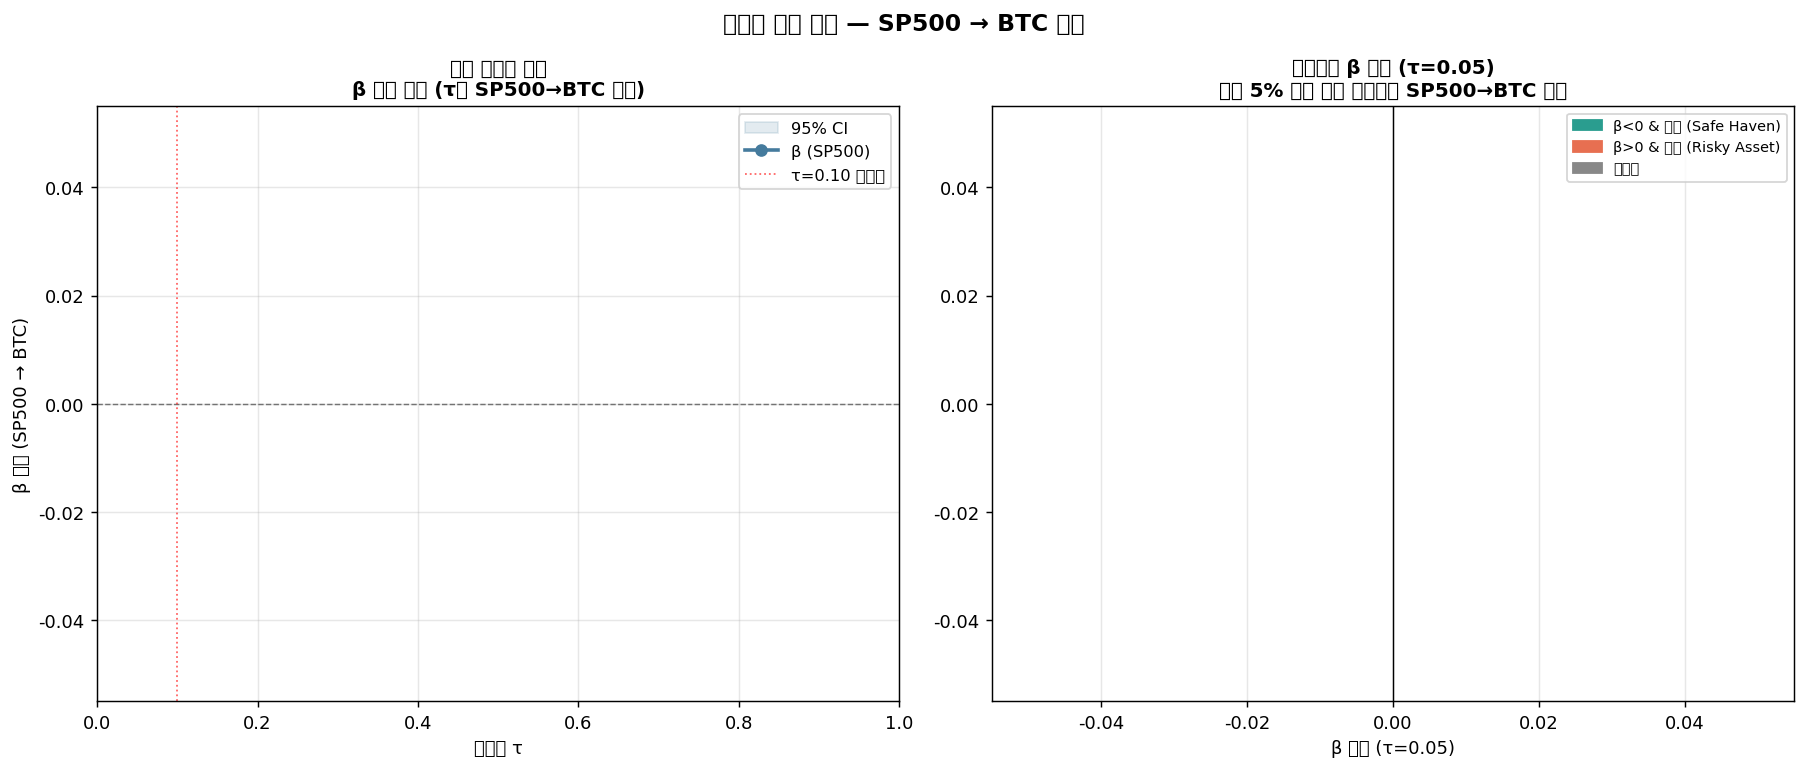

✅ quantreg_beta_path.png 저장


In [7]:
# ── 5-1. β 계수 경로 (Coefficient Plot) ─────────────
# τ가 증가할수록 β가 어떻게 변하는지 → Safe-Haven이면 하위 τ에서 β < 0

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 전체 합산 β 경로
ax = axes[0]
taus_done = [t for t in TAUS if results_all.get(t) is not None]
betas, ci_lo, ci_hi = [], [], []

for tau in taus_done:
    res = results_all[tau]
    x_cols = res['x_cols']
    sp_i   = x_cols.index('SP500_z') if 'SP500_z' in x_cols else None
    if sp_i is not None:
        betas.append(res['params'][sp_i])
        ci_lo.append(res['conf_int'][sp_i, 0])
        ci_hi.append(res['conf_int'][sp_i, 1])
    else:
        betas.append(np.nan)
        ci_lo.append(np.nan)
        ci_hi.append(np.nan)

betas  = np.array(betas)
ci_lo  = np.array(ci_lo)
ci_hi  = np.array(ci_hi)

ax.fill_between(taus_done, ci_lo, ci_hi, alpha=0.15, color='#457B9D', label='95% CI')
ax.plot(taus_done, betas, 'o-', color='#457B9D', lw=2, ms=6, label='β (SP500)')
ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
ax.axvline(0.10, color='red', lw=1, ls=':', alpha=0.6, label='τ=0.10 기준선')
_valid_lo = ci_lo[np.isfinite(ci_lo)]
_valid_hi = ci_hi[np.isfinite(ci_hi)]
if len(_valid_lo) > 0 and len(_valid_hi) > 0:
    ax.fill_betweenx([_valid_lo.min()-0.01,
                       _valid_hi.max()+0.01],
                      0, 0.10, alpha=0.06, color='red')
ax.set_xlabel('분위수 τ')
ax.set_ylabel('β 계수 (SP500 → BTC)')
ax.set_title('전체 이벤트 합산\nβ 계수 경로 (τ별 SP500→BTC 관계)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)

# 이벤트별 τ=0.05 β 비교
ax2 = axes[1]
ev_names, ev_betas, ev_colors = [], [], []
for event in EVENT_DATES:
    res = results_event.get(event, {}).get(0.05)
    if res is None:
        continue
    x_cols = res['x_cols']
    sp_i   = x_cols.index('SP500_z') if 'SP500_z' in x_cols else None
    if sp_i is None:
        continue
    b  = res['params'][sp_i]
    pb = res['pvalues'][sp_i]
    ev_names.append(EVENT_LABELS.get(event, event))
    ev_betas.append(b)
    ev_colors.append('#2A9D8F' if (pb<0.05 and b<0)
                     else '#E76F51' if (pb<0.05 and b>0)
                     else '#888')

bars = ax2.barh(ev_names, ev_betas, color=ev_colors, alpha=0.85)
ax2.axvline(0, color='black', lw=0.8)
ax2.set_xlabel('β 계수 (τ=0.05)')
ax2.set_title('이벤트별 β 계수 (τ=0.05)\n하위 5% 극단 하락 구간에서 SP500→BTC 관계',
               fontsize=11, fontweight='bold')

legend_els = [
    mpatches.Patch(color='#2A9D8F', label='β<0 & 유의 (Safe Haven)'),
    mpatches.Patch(color='#E76F51', label='β>0 & 유의 (Risky Asset)'),
    mpatches.Patch(color='#888',    label='비유의'),
]
ax2.legend(handles=legend_els, fontsize=8)
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('분위수 회귀 결과 — SP500 → BTC 계수', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('quantreg_beta_path.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ quantreg_beta_path.png 저장')

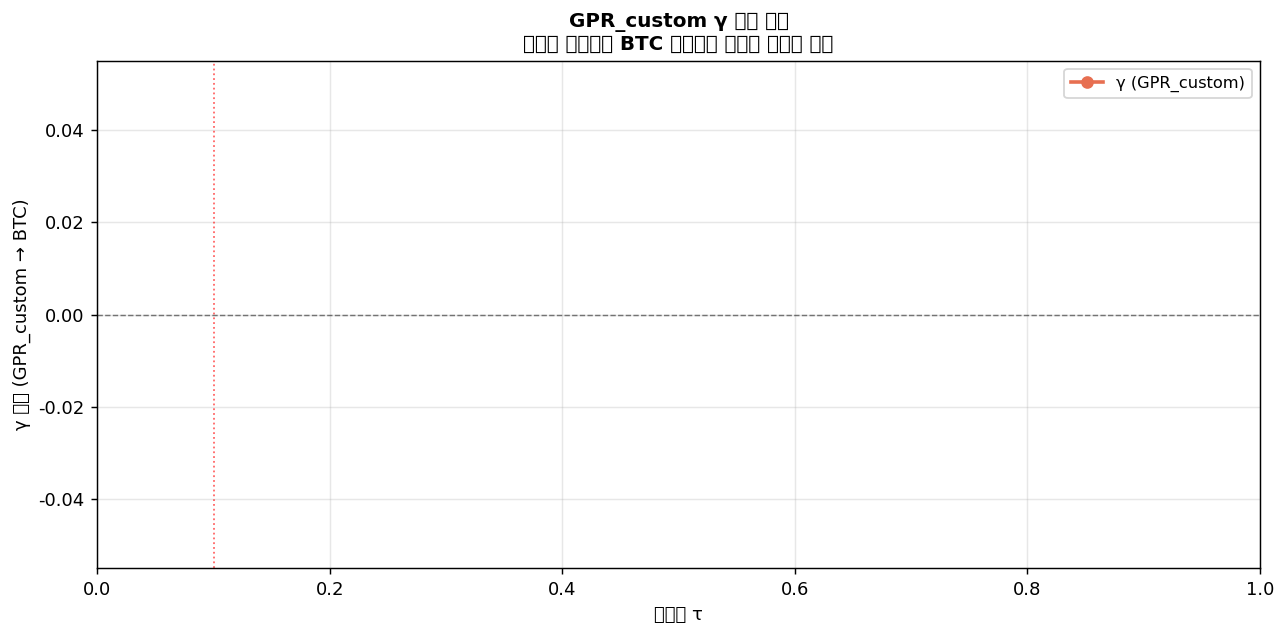

✅ quantreg_gamma_path.png 저장


In [8]:
# ── 5-2. γ 계수 경로 (GPR_custom → BTC) ─────────────
fig, ax = plt.subplots(figsize=(10, 5))

gammas, g_ci_lo, g_ci_hi = [], [], []
for tau in taus_done:
    res    = results_all[tau]
    x_cols = res['x_cols']
    gpr_i  = x_cols.index('GPR_custom_z') if 'GPR_custom_z' in x_cols else None
    if gpr_i is not None:
        gammas.append(res['params'][gpr_i])
        g_ci_lo.append(res['conf_int'][gpr_i, 0])
        g_ci_hi.append(res['conf_int'][gpr_i, 1])
    else:
        gammas.append(np.nan)
        g_ci_lo.append(np.nan)
        g_ci_hi.append(np.nan)

gammas  = np.array(gammas)
g_ci_lo = np.array(g_ci_lo)
g_ci_hi = np.array(g_ci_hi)

ax.fill_between(taus_done, g_ci_lo, g_ci_hi, alpha=0.15, color='#E76F51')
ax.plot(taus_done, gammas, 'o-', color='#E76F51', lw=2, ms=6, label='γ (GPR_custom)')
ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
ax.axvline(0.10, color='red', lw=1, ls=':', alpha=0.6)
ax.set_xlabel('분위수 τ')
ax.set_ylabel('γ 계수 (GPR_custom → BTC)')
ax.set_title('GPR_custom γ 계수 경로\n지정학 리스크가 BTC 수익률에 미치는 분위별 영향',
              fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('quantreg_gamma_path.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ quantreg_gamma_path.png 저장')

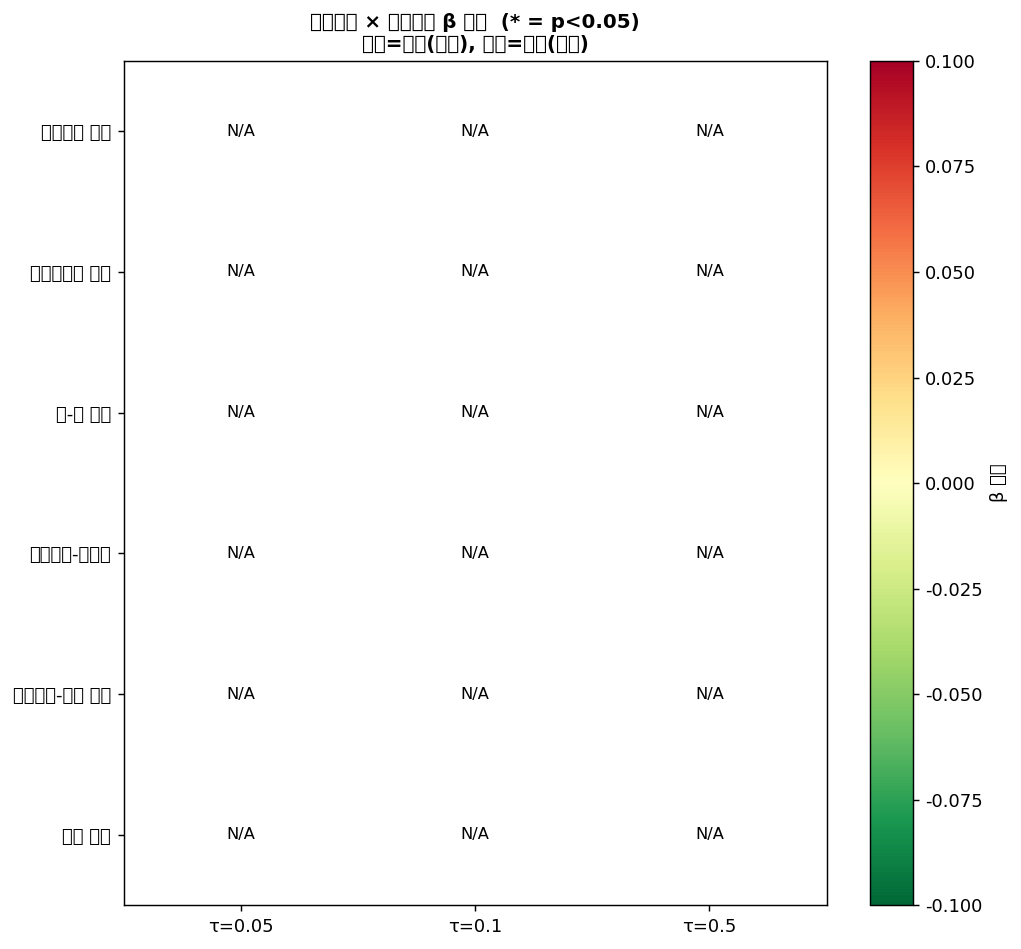

✅ quantreg_heatmap.png 저장


In [9]:
# ── 5-3. 이벤트별 × τ별 히트맵 ──────────────────────
# τ=0.05, 0.10, 0.50에서 이벤트별 β 색깔로 표시

events_list = [ev for ev in EVENT_DATES if results_event.get(ev)]
tau_list    = CORE_TAUS

beta_matrix = np.full((len(events_list), len(tau_list)), np.nan)
sig_matrix  = np.full((len(events_list), len(tau_list)), False)

for i, ev in enumerate(events_list):
    for j, tau in enumerate(tau_list):
        res = results_event.get(ev, {}).get(tau)
        if res is None:
            continue
        x_cols = res['x_cols']
        sp_i   = x_cols.index('SP500_z') if 'SP500_z' in x_cols else None
        if sp_i is not None:
            beta_matrix[i, j] = res['params'][sp_i]
            sig_matrix[i, j]  = res['pvalues'][sp_i] < 0.05

fig, ax = plt.subplots(figsize=(8, max(4, len(events_list)*0.9+2)))
vabs = np.nanmax(np.abs(beta_matrix))
im = ax.imshow(beta_matrix, cmap='RdYlGn_r', vmin=-vabs, vmax=vabs, aspect='auto')
plt.colorbar(im, ax=ax, label='β 계수')

for i in range(len(events_list)):
    for j in range(len(tau_list)):
        val = beta_matrix[i, j]
        txt = f'{val:.3f}' if not np.isnan(val) else 'N/A'
        star = '*' if sig_matrix[i, j] else ''
        color = 'white' if abs(val) > vabs*0.5 and not np.isnan(val) else 'black'
        ax.text(j, i, f'{txt}{star}', ha='center', va='center',
                fontsize=9, color=color)

ax.set_xticks(range(len(tau_list)))
ax.set_xticklabels([f'τ={t}' for t in tau_list])
ax.set_yticks(range(len(events_list)))
ax.set_yticklabels([EVENT_LABELS.get(e,e) for e in events_list])
ax.set_title('이벤트별 × 분위수별 β 계수  (* = p<0.05)\n빨강=양수(위험), 초록=음수(안전)',
              fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('quantreg_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ quantreg_heatmap.png 저장')

---
## Step 6. 최종 판단 — Baur & Lucey (2010)

In [10]:
print('=' * 75)
print('분위수 회귀 Safe-Haven 최종 판단')
print('=' * 75)
print()
print('[전체 이벤트 합산]\n')
print(f'{"τ":>6} {"β(SP500)":>10} {"p(β)":>8} {"유의":>6} {"결론"}')
print('-' * 55)

for tau in CORE_TAUS:
    res = results_all.get(tau)
    if res is None:
        print(f'{tau:>6.2f}  데이터 부족')
        continue
    x_cols = res['x_cols']
    sp_i   = x_cols.index('SP500_z') if 'SP500_z' in x_cols else None
    if sp_i is None:
        continue
    b   = res['params'][sp_i]
    pb  = res['pvalues'][sp_i]
    sig = '✅' if pb < 0.05 else '—'
    if tau <= 0.10:
        if pb<0.05 and b<0:
            verdict = '✅ Safe Haven — 주가 폭락 시 BTC 반대 방향'
        elif pb<0.05 and b>0:
            verdict = '❌ Risky Asset — 주가 폭락 시 BTC도 하락'
        else:
            verdict = '⚪ 비유의 — 통계적으로 불확실'
    else:
        verdict = f'평상시 β={b:.4f}  (비교용)'
    print(f'{tau:>6.2f} {b:>10.5f} {pb:>8.4f} {sig:>6}  {verdict}')

print()
print('[이벤트별 Safe-Haven 판정 요약]\n')
summary_rows = []
for ev in EVENT_DATES:
    row = {'이벤트': EVENT_LABELS.get(ev, ev)}
    for tau in CORE_TAUS:
        res = results_event.get(ev, {}).get(tau)
        if res is None:
            row[f'τ={tau}'] = 'N/A'
            continue
        x_cols = res['x_cols']
        sp_i   = x_cols.index('SP500_z') if 'SP500_z' in x_cols else None
        if sp_i is None:
            row[f'τ={tau}'] = 'N/A'
            continue
        b  = res['params'][sp_i]
        pb = res['pvalues'][sp_i]
        if tau <= 0.10:
            if pb<0.05 and b<0:
                row[f'τ={tau}'] = '✅ SH'
            elif pb<0.05 and b>0:
                row[f'τ={tau}'] = '❌ RA'
            elif b<0:
                row[f'τ={tau}'] = '🔵 Weak'
            else:
                row[f'τ={tau}'] = '⚪'
        else:
            row[f'τ={tau}'] = f'{b:+.4f}'
    summary_rows.append(row)

display(pd.DataFrame(summary_rows).set_index('이벤트'))

분위수 회귀 Safe-Haven 최종 판단

[전체 이벤트 합산]

     τ   β(SP500)     p(β)     유의 결론
-------------------------------------------------------
  0.05  데이터 부족
  0.10  데이터 부족
  0.50  데이터 부족

[이벤트별 Safe-Haven 판정 요약]



,τ=0.05,τ=0.1,τ=0.5
이벤트,,,
호르무즈 위기,N/A,N/A,N/A
솔레이마니 암살,N/A,N/A,N/A
러-우 전쟁,N/A,N/A,N/A
이스라엘-하마스,N/A,N/A,N/A
이스라엘-이란 충돌,N/A,N/A,N/A
이란 전쟁,N/A,N/A,N/A


---
## Step 7. 결과 저장

In [11]:
# 전체 결과 테이블
all_rows = []
for tau in TAUS:
    res = results_all.get(tau)
    if res is None:
        continue
    x_cols  = res['x_cols']
    sp_i    = x_cols.index('SP500_z')     if 'SP500_z'     in x_cols else None
    gpr_i   = x_cols.index('GPR_custom_z') if 'GPR_custom_z' in x_cols else None
    const_i = x_cols.index('const')
    all_rows.append({
        'scope' : '전체',
        'event' : 'all',
        'tau'   : tau,
        'n'     : res['n'],
        'alpha' : round(res['params'][const_i], 6),
        'beta_sp500'  : round(res['params'][sp_i],  6) if sp_i  is not None else np.nan,
        'p_beta'      : round(res['pvalues'][sp_i], 4) if sp_i  is not None else np.nan,
        'gamma_gpr'   : round(res['params'][gpr_i], 6) if gpr_i is not None else np.nan,
        'p_gamma'     : round(res['pvalues'][gpr_i],4) if gpr_i is not None else np.nan,
    })

for ev in EVENT_DATES:
    for tau in CORE_TAUS:
        res = results_event.get(ev, {}).get(tau)
        if res is None:
            continue
        x_cols  = res['x_cols']
        sp_i    = x_cols.index('SP500_z')     if 'SP500_z'     in x_cols else None
        gpr_i   = x_cols.index('GPR_custom_z') if 'GPR_custom_z' in x_cols else None
        const_i = x_cols.index('const')
        all_rows.append({
            'scope' : '이벤트별',
            'event' : ev,
            'tau'   : tau,
            'n'     : res['n'],
            'alpha' : round(res['params'][const_i], 6),
            'beta_sp500'  : round(res['params'][sp_i],  6) if sp_i  is not None else np.nan,
            'p_beta'      : round(res['pvalues'][sp_i], 4) if sp_i  is not None else np.nan,
            'gamma_gpr'   : round(res['params'][gpr_i], 6) if gpr_i is not None else np.nan,
            'p_gamma'     : round(res['pvalues'][gpr_i],4) if gpr_i is not None else np.nan,
        })

result_df = pd.DataFrame(all_rows)
result_df.to_csv('quantreg_results.csv', index=False, encoding='utf-8-sig')

print('▶ 최종 산출물:')
for f in ['quantreg_results.csv',
          'quantreg_beta_path.png',
          'quantreg_gamma_path.png',
          'quantreg_heatmap.png']:
    flag = '✅' if os.path.exists(f) else '📄 (실행 후 생성)'
    print(f'  {flag} {f}')

▶ 최종 산출물:
  ✅ quantreg_results.csv
  ✅ quantreg_beta_path.png
  ✅ quantreg_gamma_path.png
  ✅ quantreg_heatmap.png


## Step 8. 강건성 검정 추가(상호작용 항 아닌 버전)

---
### 강건성 ① 독립변수 변경 검정

GPR_custom을 제거하고 SP500, Gold만 독립변수로 쓸 때 β 계수가 바뀌는지 확인해요.
GPR이 SP500m Gold 효과를 왜곡시키는지 파악할 수 있어요.

---

**[기존 모델]** (GPR 포함)
$$Q_{\tau}(BTC) = \alpha + \beta_1(Asset) + \beta_2(GPR) + \epsilon$$

**[수정 모델]** (GPR 제거)
$$Q_{\tau}(BTC) = \alpha + \beta_1(Asset) + \epsilon$$


- **해당 모델의 효과** :  $\beta_1$ 값을 나란히 놓고 비교하여 방향 일치 여부와 수치 변화율을 계산함
- 분위수 회귀 수행은 동일 + 비교 분석 기능의 추가
- GPR 제거시의 방향성 체크 - 계수의 부호($+ / -$)가 바뀌는지 확인 / 기존과 수정 모델의 결과 차이를 기준으로 자동 판정
----
### ratio 하이퍼파라미터
: GPR을 뺐을 때 $\beta$ 값이 기존 대비 20% 이상 변하면 '왜곡'으로 볼 것인지 정하는 기준 (처음에 30%하고 더 보수적으로 20% 했는데도, 문제 없어서 20%로 픽스 - 해당 파라미터는 주관적 견해라 특정한 논문 참조 없음)
- 식: ratio = 1 + (변화율/100)
  > ex. ratio = 1.2가 20% 의미

In [12]:
# ══════════════════════════════════════════════════════
# 강건성 ② 독립변수 변경 검정
# SP500: GPR 포함 vs 제거
# Gold:  GPR 포함 vs 제거
# ══════════════════════════════════════════════════════

print('▶ 강건성 ② 독립변수 변경 검정 (전체 합산)\n')
print('  [기존] Q_τ(BTC) = α + β·X + γ·GPR_custom_z')
print('  [수정] Q_τ(BTC) = α + β·X  (GPR 제거)')
print('  → GPR이 X(SP500/Gold)의 β 추정을 왜곡하는지 확인\n')

# 검정할 자산 × 모델 조합
ROBUST_TARGETS = {
    'SP500': {
        'with_gpr': ['SP500_z', 'GPR_custom_z'],
        'without' : ['SP500_z'],
        'main_var': 'SP500_z',
    },
    'Gold': {
        'with_gpr': ['Gold_z', 'GPR_custom_z'],
        'without' : ['Gold_z'],
        'main_var': 'Gold_z',
    },
}

robust_iv_rows = []

for asset_name, cfg in ROBUST_TARGETS.items():

    print(f'  {"─"*60}')
    print(f'  [{asset_name}]')
    print(f'  기존: Q_τ(BTC) = α + β·{cfg["main_var"]} + γ·GPR_custom_z')
    print(f'  수정: Q_τ(BTC) = α + β·{cfg["main_var"]}')
    print(f'  {"─"*60}')
    print(f'  {"τ":>6} {"β 기존":>10} {"p 기존":>8} '
          f'{"β 수정":>10} {"p 수정":>8} '
          f'{"차이":>9} {"변화율":>8} {"방향일치":>10} {"판정"}')
    print('  ' + '-' * 90)

    asset_rows = []

    for tau in TAUS:                        # CORE_TAUS → TAUS 전체로 확장
        # ── 기존: GPR 포함 ────────────────────────────────────
        res_with = run_quantreg_hac(        # ← run_quantreg → run_quantreg_hac
            data_all, tau,
            x_cols=cfg['with_gpr']
        )
        # ── 수정: GPR 제거 ────────────────────────────────────
        res_wo = run_quantreg_hac(
            data_all, tau,
            x_cols=cfg['without']
        )

        if res_with is None or res_wo is None:
            print(f'  {tau:>6.2f}  데이터 부족')
            continue

        main_var = cfg['main_var']
        x_with   = res_with['x_cols']
        x_wo     = res_wo['x_cols']

        i_with = x_with.index(main_var) if main_var in x_with else None
        i_wo   = x_wo.index(main_var)   if main_var in x_wo   else None

        if i_with is None or i_wo is None:
            print(f'  {tau:>6.2f}  변수 인덱스 오류')
            continue

        b_with  = res_with['params'][i_with]
        pb_with = res_with['pvalues'][i_with]
        b_wo    = res_wo['params'][i_wo]
        pb_wo   = res_wo['pvalues'][i_wo]

        diff = b_wo - b_with

        # ── 변화율 (b_with=0 방어) ────────────────────────────
        if abs(b_with) > 1e-10:
            change_pct = diff / abs(b_with) * 100
            change_str = f'{change_pct:>+7.1f}%'
        else:
            change_str = '   N/A  '

        # ── 방향 일치 판정 (0값 엣지케이스 방어) ─────────────
        if abs(b_with) < 1e-10 or abs(b_wo) < 1e-10:
            same_dir = '⚠️ 0근접'
        elif b_with * b_wo > 0:
            same_dir = '✅ 일치'
        else:
            same_dir = '🔴 반전'

        # ── 크기 변화 판정 ────────────────────────────────────
        if same_dir == '✅ 일치':
            if abs(b_with) > 1e-10:
                ratio = abs(b_wo) / abs(b_with)
                if ratio > 1.20:
                    size_judge = 'β 20% 이상 증폭'
                elif ratio < 0.80:
                    size_judge = 'β 20% 이상 감소'
                else:
                    size_judge = 'β 안정적 (±20% 이내)'
            else:
                size_judge = '—'
        else:
            size_judge = '⚠️ 방향 반전 → GPR 왜곡 의심'

        sig_with = '✅' if pb_with < 0.05 else '△' if pb_with < 0.10 else '—'
        sig_wo   = '✅' if pb_wo   < 0.05 else '△' if pb_wo   < 0.10 else '—'

        print(f'  {tau:>6.2f} '
              f'{b_with:>10.5f}{sig_with:>2} {pb_with:>7.4f} '
              f'{b_wo:>10.5f}{sig_wo:>2} {pb_wo:>7.4f} '
              f'{diff:>+9.5f} {change_str:>8} '
              f'{same_dir:>10}  {size_judge}')

        asset_rows.append({
            '자산'      : asset_name,
            'τ'         : tau,
            'β_기존'    : round(b_with, 5),
            'p_기존'    : round(pb_with, 4),
            'β_GPR제거' : round(b_wo, 5),
            'p_GPR제거' : round(pb_wo, 4),
            '차이'      : round(diff, 5),
            '방향일치'  : same_dir,
            '판정'      : size_judge,
        })
        robust_iv_rows.append(asset_rows[-1])

    # ── 자산별 소결론 ──────────────────────────────────────
    if asset_rows:
        match_count   = sum(1 for r in asset_rows if '일치' in r['방향일치'])
        reverse_count = sum(1 for r in asset_rows if '반전' in r['방향일치'])
        total         = len(asset_rows)

        print(f'\n  ▶ [{asset_name}] 소결론')
        print(f'     방향 일치: {match_count}/{total}개 분위수')

        if reverse_count == 0:
            print(f'     ✅ GPR 제거해도 β 방향 동일')
            print(f'        → {asset_name} 효과가 GPR 포함 여부와 무관 (강건)')
        elif reverse_count <= total * 0.3:
            print(f'     🔶 일부({reverse_count}개) 분위수에서 방향 반전')
            print(f'        → 특정 구간에서 GPR이 {asset_name} 효과 추정에 영향')
        else:
            print(f'     🔴 과반({reverse_count}개) 방향 반전')
            print(f'        → GPR이 {asset_name} 효과 추정을 심하게 왜곡')
    print()

# ── 전체 요약 ──────────────────────────────────────────────
print('═' * 60)
print('▶ 강건성 ② 최종 요약')
print('═' * 60)

for asset_name in ROBUST_TARGETS:
    rows_asset = [r for r in robust_iv_rows if r['자산'] == asset_name]
    if not rows_asset:
        continue
    match   = sum(1 for r in rows_asset if '일치' in r['방향일치'])
    reverse = sum(1 for r in rows_asset if '반전' in r['방향일치'])
    total   = len(rows_asset)
    icon    = '✅' if reverse == 0 else '🔶' if reverse <= total*0.3 else '🔴'
    print(f'  {icon} {asset_name:<8} '
          f'방향일치 {match}/{total}  '
          f'{"GPR 포함 여부와 무관 (강건)" if reverse==0 else "GPR 왜곡 존재"}')

# DataFrame 저장
robust_iv_df = pd.DataFrame(robust_iv_rows)
print(f'\n  robust_iv_df: {len(robust_iv_df)}행 저장 완료')

▶ 강건성 ② 독립변수 변경 검정 (전체 합산)

  [기존] Q_τ(BTC) = α + β·X + γ·GPR_custom_z
  [수정] Q_τ(BTC) = α + β·X  (GPR 제거)
  → GPR이 X(SP500/Gold)의 β 추정을 왜곡하는지 확인

  ────────────────────────────────────────────────────────────
  [SP500]
  기존: Q_τ(BTC) = α + β·SP500_z + γ·GPR_custom_z
  수정: Q_τ(BTC) = α + β·SP500_z
  ────────────────────────────────────────────────────────────
       τ       β 기존     p 기존       β 수정     p 수정        차이      변화율       방향일치 판정
  ------------------------------------------------------------------------------------------
    0.01    0.02552 ✅  0.0000    0.02558 ✅  0.0000  +0.00006    +0.2%       ✅ 일치  β 안정적 (±20% 이내)
    0.03    0.02099 ✅  0.0000    0.01968 ✅  0.0000  -0.00130    -6.2%       ✅ 일치  β 안정적 (±20% 이내)
    0.05    0.01783 ✅  0.0000    0.01740 ✅  0.0000  -0.00043    -2.4%       ✅ 일치  β 안정적 (±20% 이내)
    0.10    0.01588 ✅  0.0000    0.01595 ✅  0.0000  +0.00007    +0.5%       ✅ 일치  β 안정적 (±20% 이내)
    0.20    0.01303 ✅  0.0000    0.01320 ✅  0.0000  +0.00017    +1.3%  

    0.75    0.00983 ✅  0.0000    0.00982 ✅  0.0000  -0.00001    -0.1%       ✅ 일치  β 안정적 (±20% 이내)
    0.90    0.00939 ✅  0.0004    0.00858 ✅  0.0016  -0.00080    -8.5%       ✅ 일치  β 안정적 (±20% 이내)
    0.95    0.00933 ✅  0.0013    0.00961 ✅  0.0009  +0.00027    +2.9%       ✅ 일치  β 안정적 (±20% 이내)

  ▶ [SP500] 소결론
     방향 일치: 10/10개 분위수
     ✅ GPR 제거해도 β 방향 동일
        → SP500 효과가 GPR 포함 여부와 무관 (강건)

  ────────────────────────────────────────────────────────────
  [Gold]
  기존: Q_τ(BTC) = α + β·Gold_z + γ·GPR_custom_z
  수정: Q_τ(BTC) = α + β·Gold_z
  ────────────────────────────────────────────────────────────
       τ       β 기존     p 기존       β 수정     p 수정        차이      변화율       방향일치 판정
  ------------------------------------------------------------------------------------------


    0.01    0.01449 ✅  0.0000    0.01664 ✅  0.0000  +0.00214   +14.8%       ✅ 일치  β 안정적 (±20% 이내)


    0.03    0.00689 ✅  0.0012    0.00705 ✅  0.0008  +0.00016    +2.3%       ✅ 일치  β 안정적 (±20% 이내)
    0.05    0.00598 ✅  0.0005    0.00617 ✅  0.0003  +0.00019    +3.2%       ✅ 일치  β 안정적 (±20% 이내)
    0.10    0.00389 ✅  0.0050    0.00383 ✅  0.0057  -0.00007    -1.8%       ✅ 일치  β 안정적 (±20% 이내)
    0.20    0.00354 ✅  0.0035    0.00346 ✅  0.0041  -0.00007    -2.1%       ✅ 일치  β 안정적 (±20% 이내)
    0.25    0.00241 ✅  0.0393    0.00243 ✅  0.0371  +0.00002    +0.9%       ✅ 일치  β 안정적 (±20% 이내)
    0.50    0.00375 ✅  0.0007    0.00364 ✅  0.0010  -0.00011    -3.1%       ✅ 일치  β 안정적 (±20% 이내)
    0.75    0.00366 ✅  0.0019    0.00385 ✅  0.0010  +0.00020    +5.4%       ✅ 일치  β 안정적 (±20% 이내)
    0.90    0.00166 —  0.2628    0.00164 —  0.2619  -0.00002    -1.2%       ✅ 일치  β 안정적 (±20% 이내)


    0.95    0.00490 ✅  0.0055    0.00462 ✅  0.0084  -0.00027    -5.6%       ✅ 일치  β 안정적 (±20% 이내)

  ▶ [Gold] 소결론
     방향 일치: 10/10개 분위수
     ✅ GPR 제거해도 β 방향 동일
        → Gold 효과가 GPR 포함 여부와 무관 (강건)

════════════════════════════════════════════════════════════
▶ 강건성 ② 최종 요약
════════════════════════════════════════════════════════════
  ✅ SP500    방향일치 10/10  GPR 포함 여부와 무관 (강건)
  ✅ Gold     방향일치 10/10  GPR 포함 여부와 무관 (강건)

  robust_iv_df: 20행 저장 완료


#### 결과 정리 

1) 전쟁 지수(GPR)를 모델에 넣었을 때와 뺐을 때, 주식(SP500)과 금(Gold)의 영향력($\beta$)이 변하는지 확인
2) SP500 모델: 매우 안정성
- 방향 일치: 모든 분위수(10/10)에서 방향이 일치
- 최대 변화율: 가장 크게 변한 구간($\tau=0.90$)에서도 -8.5%, 나머지 대부분 1% 내외 수준
- 비트코인이 주식과 동조화되는 성질은 **GPR이라는 변수가 있든 없든 상관없이 발생**
3) Gold 모델:
- 방향 일치: 모든 분위수(10/10)에서 방향이 일치
- 변화율: $\tau=0.01$ 구간에서 +14.8%로 가장 큰 변화가 있었으나, 20% 내에서는 들어옴.
- 금 모델에서 비트코인이 위험 자산으로 판정된 결과도 GPR에 의한 것이 아님

**한줄 정리** 
판정 기준을 30%에서 20%로 상향 조정했음에도 불구하고, SP500과 Gold 모델 모두에서 방향 일치와 수치적 안정성이 확인

---
### 강건성 ② 이벤트별 제외 검정 (Leave-One-Out)

이벤트를 하나씩 제외했을 때 전체 합산 결과가 어떻게 변하는지 확인해요.
특정 이벤트가 결과를 지배하고 있는지 파악할 수 있어요.

----
수정 로직 
1) 반복적 리샘플링: 전체 데이터에서 특정 이벤트 기간을 통째로 들어내고 모델을 반복 실행
2) 각 이벤트가 제외될 때마다 $\beta$ 값이 얼마나 변동되는지 계산하여, 가장 큰 영향을 미치는 이벤트가 무엇인지 순위 제공


---
### 하이퍼파라미터

- critical 변수 (판정 반전 기준)
  : 어떤 변화를 '🔴 심각한 결함'으로 볼 것인가를 정하는 것으로, Safe Haven ↔ Risky Asset처럼 아예 정반대로 뒤집히는 경우를 '반전'으로 정의함(안 쓰임 - 해당 결과 없음)

---
### 판정 로직 계산 풀이
> $\Delta\beta$ (델타 베타) 계산: $\Delta\beta = \beta_{loo(i)} - \beta_{base}$
- $\Delta\beta$가 양수(+)면: 해당 이벤트를 뺐을 때 동조화가 더 심해짐 $\rightarrow$ 뺀 이벤트가 사실은 동조화를 완화해주고 있었음.
- $\Delta\beta$가 음수(-)면: 해당 이벤트를 뺐을 때 동조화가 약해짐 $\rightarrow$ 뺀 이벤트가 동조화를 주도하고 있었음.

In [13]:
# ══════════════════════════════════════════════════════
# 강건성 ③ Leave-One-Out 검정
# ══════════════════════════════════════════════════════

def get_beta(res, var):
    """결과에서 특정 변수의 β, p 추출 헬퍼"""
    if res is None:
        return np.nan, np.nan
    x_cols = res['x_cols']
    if var not in x_cols:
        return np.nan, np.nan
    i = x_cols.index(var)
    return res['params'][i], res['pvalues'][i]


def classify_verdict(b, p):
    """β, p → 판정 문자열"""
    if pd.isna(b) or pd.isna(p):
        return '판정불가'
    if p < 0.05 and b < 0:
        return 'Safe Haven'
    if p < 0.05 and b > 0:
        return 'Risky Asset'
    if p < 0.10 and b < 0:
        return 'Weak SH'
    return '비유의'


def verdict_changed(v_base, v_loo):
    """판정 변화 여부 및 심각도"""
    if v_base == v_loo:
        return '✅ 동일'
    # Safe Haven ↔ Risky Asset 반전은 가장 심각
    critical = {'Safe Haven', 'Risky Asset'}
    if v_base in critical and v_loo in critical:
        return '🔴 판정 반전!'
    return '⚠️ 판정 변화'


# ── 검정 대상 자산 정의 ───────────────────────────────────────────
LOO_TARGETS = {
    'SP500': {
        'x_cols'  : ['SP500_z', 'GPR_custom_z'],
        'main_var': 'SP500_z',
    },
    'Gold': {
        'x_cols'  : ['Gold_z', 'GPR_custom_z'],
        'main_var': 'Gold_z',
    },
}

print('▶ 강건성 ③ Leave-One-Out 검정\n')
print('  이벤트를 하나씩 제외했을 때 전체 결과가 얼마나 변하는지 확인')
print('  → 특정 이벤트가 결론을 지배하는지 파악\n')

loo_rows    = []
all_results = {}   # 자산별 LOO 결과 저장

for asset_name, cfg in LOO_TARGETS.items():
    main_var = cfg['main_var']
    x_cols   = cfg['x_cols']

    print(f'\n{"═"*85}')
    print(f'  [{asset_name}]  '
          f'모델: BTC = α + β·{main_var} + γ·GPR_custom_z')
    print(f'{"═"*85}')

    # ── 기준선: 전체 데이터 ───────────────────────────────────
    res_base_05 = run_quantreg_hac(data_all, 0.05, x_cols=x_cols)
    res_base_10 = run_quantreg_hac(data_all, 0.10, x_cols=x_cols)

    b05_base, p05_base = get_beta(res_base_05, main_var)
    b10_base, p10_base = get_beta(res_base_10, main_var)

    v05_base = classify_verdict(b05_base, p05_base)
    v10_base = classify_verdict(b10_base, p10_base)

    sig05 = '✅' if p05_base < 0.05 else '△' if p05_base < 0.10 else '—'
    sig10 = '✅' if p10_base < 0.05 else '△' if p10_base < 0.10 else '—'

    # 헤더
    print(f'\n  {"제외 이벤트":<24} '
          f'{"τ=0.05 β":>10} {"p":>7} {"판정05":<14} '
          f'{"τ=0.10 β":>10} {"p":>7} {"판정10":<14} '
          f'{"결론 변화"}')
    print('  ' + '-' * 105)

    # 기준선 출력
    print(f'  {"[전체 포함 기준]":<24} '
          f'{b05_base:>10.5f}{sig05} {p05_base:>6.4f} {v05_base:<14} '
          f'{b10_base:>10.5f}{sig10} {p10_base:>6.4f} {v10_base:<14} '
          f'(기준선)')
    print('  ' + '-' * 105)

    asset_loo_rows = []

    for excl_event, excl_label in EVENT_LABELS.items():

        # 해당 이벤트 제외
        data_loo = data_all[
            data_all['event_name'] != excl_event
        ].copy()

        n_loo = len(data_loo.dropna(
            subset=['BTC'] + [c for c in x_cols if c in data_loo.columns]
        ))

        if n_loo < 30:
            print(f'  {excl_label:<24}  ⚠️ n={n_loo} < 30 → 스킵')
            continue

        # LOO 분위수 회귀
        res_05 = run_quantreg_hac(data_loo, 0.05, x_cols=x_cols)
        res_10 = run_quantreg_hac(data_loo, 0.10, x_cols=x_cols)

        b05, p05 = get_beta(res_05, main_var)
        b10, p10 = get_beta(res_10, main_var)

        v05 = classify_verdict(b05, p05)
        v10 = classify_verdict(b10, p10)

        # 변화 판정
        chg05 = verdict_changed(v05_base, v05)
        chg10 = verdict_changed(v10_base, v10)

        # 더 심각한 쪽으로 전체 판정
        if '반전' in chg05 or '반전' in chg10:
            overall = '🔴 판정 반전!'
        elif '변화' in chg05 or '변화' in chg10:
            overall = '⚠️ 판정 변화'
        else:
            overall = '✅ 동일'

        # β 변화량
        diff05 = b05 - b05_base
        diff10 = b10 - b10_base

        sig05_loo = '✅' if p05 < 0.05 else '△' if p05 < 0.10 else '—'
        sig10_loo = '✅' if p10 < 0.05 else '△' if p10 < 0.10 else '—'

        print(f'  {excl_label:<24} '
              f'{b05:>10.5f}{sig05_loo} {p05:>6.4f} {v05:<14} '
              f'{b10:>10.5f}{sig10_loo} {p10:>6.4f} {v10:<14} '
              f'{overall}')

        row = {
            '자산'       : asset_name,
            '제외이벤트' : excl_label,
            'n_loo'      : n_loo,
            'β_τ0.05'    : round(b05, 5),
            'p_τ0.05'    : round(p05, 4),
            'v_τ0.05'    : v05,
            'Δβ_0.05'    : round(diff05, 5),
            'β_τ0.10'    : round(b10, 5),
            'p_τ0.10'    : round(p10, 4),
            'v_τ0.10'    : v10,
            'Δβ_0.10'    : round(diff10, 5),
            '결론변화'   : overall,
        }
        asset_loo_rows.append(row)
        loo_rows.append(row)

    # ── 자산별 영향력 순위 ─────────────────────────────────
    if asset_loo_rows:
        print(f'\n  ▶ [{asset_name}] β 변화량 순위 (τ=0.05 기준, 영향 큰 순)')
        sorted_rows = sorted(asset_loo_rows,
                             key=lambda r: abs(r['Δβ_0.05']),
                             reverse=True)
        for rank, r in enumerate(sorted_rows, 1):
            bar_len = int(abs(r['Δβ_0.05']) / 0.001)   # 스케일 조정
            bar     = '█' * min(bar_len, 30)
            sign    = '+' if r['Δβ_0.05'] > 0 else '-'
            print(f'    {rank}위 {r["제외이벤트"]:<22} '
                  f'Δβ={r["Δβ_0.05"]:>+8.5f}  {sign}{bar}')

        # 소결론
        changed = sum(1 for r in asset_loo_rows if '동일' not in r['결론변화'])
        reverse = sum(1 for r in asset_loo_rows if '반전' in r['결론변화'])
        total   = len(asset_loo_rows)

        print(f'\n  ▶ [{asset_name}] 소결론')
        print(f'     판정 변화: {changed}/{total}개 이벤트 제외 시 변화')
        print(f'     판정 반전: {reverse}/{total}개 이벤트 제외 시 반전')

        if reverse == 0 and changed == 0:
            print(f'     ✅ 강건: 어떤 이벤트 제외해도 결론 동일')
        elif reverse > 0:
            # 반전 일으킨 이벤트 명시
            culprits = [r['제외이벤트'] for r in asset_loo_rows
                        if '반전' in r['결론변화']]
            print(f'     🔴 취약: {culprits} 제외 시 판정 반전')
            print(f'        → 해당 이벤트가 결론을 지배하고 있음')
        else:
            print(f'     🔶 주의: 일부 제외 시 판정 변화 (반전은 없음)')

        all_results[asset_name] = {
            'base': {'b05': b05_base, 'p05': p05_base,
                     'b10': b10_base, 'p10': p10_base},
            'loo' : asset_loo_rows,
        }

# ══════════════════════════════════════════════════════
# 최종 요약
# ══════════════════════════════════════════════════════
print(f'\n\n{"═"*85}')
print('▶ 강건성 ③ LOO 최종 요약')
print(f'{"═"*85}')
print(f'  {"자산":<10} {"강건성":>8} {"반전 이벤트"}')
print('  ' + '-' * 60)

for asset_name in LOO_TARGETS:
    rows_a  = [r for r in loo_rows if r['자산'] == asset_name]
    reverse = [r['제외이벤트'] for r in rows_a if '반전' in r['결론변화']]
    changed = [r['제외이벤트'] for r in rows_a if '변화' in r['결론변화']
               and '반전' not in r['결론변화']]

    if not reverse and not changed:
        icon   = '✅ 강건'
        detail = '없음'
    elif reverse:
        icon   = '🔴 취약'
        detail = ', '.join(reverse)
    else:
        icon   = '🔶 주의'
        detail = ', '.join(changed)

    print(f'  {asset_name:<10} {icon:<10} {detail}')

# DataFrame 저장
loo_df = pd.DataFrame(loo_rows)
print(f'\n  loo_df: {len(loo_df)}행 저장 완료')

▶ 강건성 ③ Leave-One-Out 검정

  이벤트를 하나씩 제외했을 때 전체 결과가 얼마나 변하는지 확인
  → 특정 이벤트가 결론을 지배하는지 파악


═════════════════════════════════════════════════════════════════════════════════════
  [SP500]  모델: BTC = α + β·SP500_z + γ·GPR_custom_z
═════════════════════════════════════════════════════════════════════════════════════

  제외 이벤트                     τ=0.05 β       p 판정05             τ=0.10 β       p 판정10           결론 변화
  ---------------------------------------------------------------------------------------------------------
  [전체 포함 기준]                  0.01783✅ 0.0000 Risky Asset       0.01588✅ 0.0000 Risky Asset    (기준선)
  ---------------------------------------------------------------------------------------------------------


  호르무즈 위기                     0.01817✅ 0.0000 Risky Asset       0.01599✅ 0.0000 Risky Asset    ✅ 동일


  솔레이마니 암살                    0.01970✅ 0.0000 Risky Asset       0.01665✅ 0.0000 Risky Asset    ✅ 동일
  러-우 전쟁                      0.01386✅ 0.0000 Risky Asset       0.01219✅ 0.0000 Risky Asset    ✅ 동일
  이스라엘-하마스                    0.01817✅ 0.0000 Risky Asset       0.01618✅ 0.0000 Risky Asset    ✅ 동일
  이스라엘-이란 충돌                  0.01587✅ 0.0000 Risky Asset       0.01566✅ 0.0000 Risky Asset    ✅ 동일
  이란 전쟁                       0.01730✅ 0.0000 Risky Asset       0.01613✅ 0.0000 Risky Asset    ✅ 동일

  ▶ [SP500] β 변화량 순위 (τ=0.05 기준, 영향 큰 순)
    1위 러-우 전쟁                 Δβ=-0.00397  -███
    2위 이스라엘-이란 충돌             Δβ=-0.00197  -█
    3위 솔레이마니 암살               Δβ=+0.00187  +█
    4위 이란 전쟁                  Δβ=-0.00054  -
    5위 이스라엘-하마스               Δβ=+0.00034  +
    6위 호르무즈 위기                Δβ=+0.00033  +

  ▶ [SP500] 소결론
     판정 변화: 0/6개 이벤트 제외 시 변화
     판정 반전: 0/6개 이벤트 제외 시 반전
     ✅ 강건: 어떤 이벤트 제외해도 결론 동일

══════════════════════════════════════════════════════════════════════════════

  호르무즈 위기                     0.00312△ 0.0617 비유의               0.00263△ 0.0558 비유의            ⚠️ 판정 변화
  솔레이마니 암살                    0.00307— 0.1048 비유의               0.00059— 0.6913 비유의            ⚠️ 판정 변화


  러-우 전쟁                      0.00422✅ 0.0123 Risky Asset       0.00409✅ 0.0046 Risky Asset    ✅ 동일
  이스라엘-하마스                    0.00476✅ 0.0068 Risky Asset       0.00510✅ 0.0005 Risky Asset    ✅ 동일


  이스라엘-이란 충돌                  0.00530✅ 0.0026 Risky Asset       0.00379✅ 0.0081 Risky Asset    ✅ 동일


  이란 전쟁                       0.00877✅ 0.0001 Risky Asset       0.00615✅ 0.0014 Risky Asset    ✅ 동일

  ▶ [Gold] β 변화량 순위 (τ=0.05 기준, 영향 큰 순)
    1위 솔레이마니 암살               Δβ=-0.00291  -██
    2위 호르무즈 위기                Δβ=-0.00286  -██
    3위 이란 전쟁                  Δβ=+0.00279  +██
    4위 러-우 전쟁                 Δβ=-0.00176  -█
    5위 이스라엘-하마스               Δβ=-0.00122  -█
    6위 이스라엘-이란 충돌             Δβ=-0.00067  -

  ▶ [Gold] 소결론
     판정 변화: 2/6개 이벤트 제외 시 변화
     판정 반전: 0/6개 이벤트 제외 시 반전
     🔶 주의: 일부 제외 시 판정 변화 (반전은 없음)


═════════════════════════════════════════════════════════════════════════════════════
▶ 강건성 ③ LOO 최종 요약
═════════════════════════════════════════════════════════════════════════════════════
  자산              강건성 반전 이벤트
  ------------------------------------------------------------
  SP500      ✅ 강건       없음
  Gold       🔶 주의       호르무즈 위기, 솔레이마니 암살

  loo_df: 12행 저장 완료


#### 강건성 검정 ②: LOO(Leave-One-Out) 분석 결과 요약

1. SP500 모델: 주식 모델은 어떤 이벤트를 제외하더라도 결론이 변하지 않는 강건성을 보임
   - 결론 유지: 6개 이벤트 중 어떤 것을 제외해도 여전히 ❌ Risky Asset 판정이 유지
   - 영향력 순위: 러-우 전쟁을 제외했을 때 $\beta$ 값이 가장 크게 감소($\Delta\beta = -0.00397$)
     > 러-우 전쟁이 비트코인과 주식의 동조화를 가장 강하게 영향을 준 사건이지만, 제외해도 결과는 유지됨.
   - 비트코인이 주식을 따라가는 위험 자산이라는 것은 특정 사건에 의한 우연이 아님.
2. Gold 모델: 금 모델은 특정 이벤트를 제외할 경우 판정이 유의미에서 비유의로 변하는 🔶 주의 단계의 결과 나옴
   - 판정 변화: 호르무즈 위기와 솔레이마니 암살 사건을 제외하면, 금과의 관계가 'Risky Asset'에서 '비유의(⚪)'로 변함
   - 해석: 이는 비트코인이 금과 나쁜 쪽으로 엮였던(❌) 성격이 주로 위 두 사건에 집중되어 있었음을 의미함
     > 즉, 금 모델에서의 위험 판정은 주식 모델 대비 특정 이벤트의 영향력에 더 민감하게 반응함
   - 비트코인이 금의 안전성을 닮지 않았다는 결론은 유효함. 다만, 주식만큼은 강하진 않음.

----
### 강건성 ③ 표준화 방법 변경 검정

-  데이터의 범위를 맞추는 표준화 방식은 계수($\beta$)의 크기에 직접적인 영향을 주기 때문에, 표준화 방법 변경
-  Z-score(평균 0, 표준편차 1) 표준화 방식에서 Min-Max 정규화로 검정

----
### 변경 로직 정리

- **[기존] Z-score 변환**
  > $X_z = \frac{X - \mu}{\sigma}$ (상대적 위치 강조)
- **[수정] Min-Max 변환**
  > $X_{mm} = \frac{X - min}{max - min}$ (절대적 범위 강조, 0~1)

1. overall 판정 로직
   - 방향과 유의성이 모두 같아야 ✅로 판정(전부 ✅로 판정하기 때문에, 보수적 변경 불필요)


In [14]:
# ══════════════════════════════════════════════════════
# 강건성 ④ 표준화 방법 변경 검정
# Z-score vs Min-Max 정규화
# SP500+GPR / Gold+GPR 두 모델 모두 검정
# ══════════════════════════════════════════════════════

# ── Min-Max 정규화 데이터 생성 ────────────────────────
norm_cols = ['SP500', 'Gold', 'GPR_custom']
data_minmax = data_all.copy()

print('▶ Min-Max 정규화 컬럼 생성')
for col in norm_cols:
    if col not in data_minmax.columns:
        print(f'  ⚠️  {col} 없음 → 스킵')
        continue
    cmin = data_minmax[col].min()
    cmax = data_minmax[col].max()
    mm_col = f'{col}_mm'
    if cmax > cmin:
        data_minmax[mm_col] = (data_minmax[col] - cmin) / (cmax - cmin)
    else:
        data_minmax[mm_col] = 0.0
        print(f'  ⚠️  {col}: min=max → 0으로 채움')
    print(f'  {col:<15} → {mm_col}  '
          f'범위: [{data_minmax[mm_col].min():.3f}, '
          f'{data_minmax[mm_col].max():.3f}]')

# ── 검정 대상 모델 정의 ───────────────────────────────
NORM_TARGETS = {
    'SP500+GPR': {
        'z_cols' : ['SP500_z',  'GPR_custom_z'],
        'mm_cols': ['SP500_mm', 'GPR_custom_mm'],
        'main_z' : 'SP500_z',
        'main_mm': 'SP500_mm',
        'gpr_z'  : 'GPR_custom_z',
        'gpr_mm' : 'GPR_custom_mm',
    },
    'Gold+GPR': {
        'z_cols' : ['Gold_z',  'GPR_custom_z'],
        'mm_cols': ['Gold_mm', 'GPR_custom_mm'],
        'main_z' : 'Gold_z',
        'main_mm': 'Gold_mm',
        'gpr_z'  : 'GPR_custom_z',
        'gpr_mm' : 'GPR_custom_mm',
    },
}

robust_mm_rows = []

print('\n▶ 강건성 ④ 표준화 방법 변경 검정\n')
print('  [기존] Z-score  (평균=0, 표준편차=1)')
print('  [수정] Min-Max  (0~1 범위)')
print('  → β 절댓값은 달라지지만 방향·유의성은 유지돼야 강건\n')

for model_name, cfg in NORM_TARGETS.items():

    print(f'{"═"*80}')
    print(f'  [{model_name}]')
    print(f'  기존: BTC = α + β·{cfg["main_z"]}  + γ·{cfg["gpr_z"]}')
    print(f'  수정: BTC = α + β·{cfg["main_mm"]} + γ·{cfg["gpr_mm"]}')
    print(f'{"═"*80}')
    print(f'  {"τ":>6} '
          f'{"β(Z)":>10} {"p(Z)":>7} '
          f'{"β(MM)":>10} {"p(MM)":>7} '
          f'{"γ(Z)":>10} {"p(γZ)":>7} '
          f'{"γ(MM)":>10} {"p(γMM)":>7} '
          f'{"방향":>8} {"유의성":>8} {"판정"}')
    print('  ' + '-' * 110)

    model_rows = []

    for tau in TAUS:

        # ── Z-score 모델 ───────────────────────────────
        res_z = run_quantreg_hac(
            data_all, tau,
            x_cols=cfg['z_cols']
        )
        # ── Min-Max 모델 ──────────────────────────────
        res_mm = run_quantreg_hac(
            data_minmax, tau,
            x_cols=cfg['mm_cols']
        )

        if res_z is None or res_mm is None:
            print(f'  {tau:>6.2f}  데이터 부족')
            continue

        xz  = res_z['x_cols']
        xmm = res_mm['x_cols']

        # 인덱스 추출
        m_z_i   = xz.index(cfg['main_z'])   if cfg['main_z']  in xz  else None
        m_mm_i  = xmm.index(cfg['main_mm']) if cfg['main_mm'] in xmm else None
        g_z_i   = xz.index(cfg['gpr_z'])    if cfg['gpr_z']   in xz  else None
        g_mm_i  = xmm.index(cfg['gpr_mm'])  if cfg['gpr_mm']  in xmm else None

        if any(i is None for i in [m_z_i, m_mm_i, g_z_i, g_mm_i]):
            print(f'  {tau:>6.2f}  인덱스 오류')
            continue

        # 계수 및 p-value
        b_z   = res_z['params'][m_z_i];    p_bz  = res_z['pvalues'][m_z_i]
        b_mm  = res_mm['params'][m_mm_i];  p_bmm = res_mm['pvalues'][m_mm_i]
        g_z   = res_z['params'][g_z_i];    p_gz  = res_z['pvalues'][g_z_i]
        g_mm  = res_mm['params'][g_mm_i];  p_gmm = res_mm['pvalues'][g_mm_i]

        # ── 방향 일치 판정 ────────────────────────────
        if abs(b_z) < 1e-10 or abs(b_mm) < 1e-10:
            dir_judge = '⚠️ 0근접'
        elif b_z * b_mm > 0:
            dir_judge = '✅ 일치'
        else:
            dir_judge = '🔴 반전'

        # ── 유의성 일치 판정 ──────────────────────────
        sig_z  = p_bz  < 0.05
        sig_mm = p_bmm < 0.05
        if sig_z == sig_mm:
            sig_judge = '✅ 유지'
        elif sig_z and not sig_mm:
            sig_judge = '⚠️ Z만유의'
        else:
            sig_judge = '⚠️ MM만유의'

        # ── 종합 판정 ─────────────────────────────────
        if dir_judge == '✅ 일치' and sig_judge == '✅ 유지':
            overall = '강건'
        elif dir_judge == '✅ 일치' and '유의' in sig_judge:
            overall = '방향강건/유의성변화'
        elif dir_judge == '🔴 반전':
            overall = '🔴 취약'
        else:
            overall = '⚠️ 주의'

        # 유의성 표시
        sb_z  = '✅' if p_bz  < 0.05 else '△' if p_bz  < 0.10 else '—'
        sb_mm = '✅' if p_bmm < 0.05 else '△' if p_bmm < 0.10 else '—'
        sg_z  = '✅' if p_gz  < 0.05 else '△' if p_gz  < 0.10 else '—'
        sg_mm = '✅' if p_gmm < 0.05 else '△' if p_gmm < 0.10 else '—'

        print(f'  {tau:>6.2f} '
              f'{b_z:>10.5f}{sb_z} {p_bz:>6.4f} '
              f'{b_mm:>10.5f}{sb_mm} {p_bmm:>6.4f} '
              f'{g_z:>10.5f}{sg_z} {p_gz:>6.4f} '
              f'{g_mm:>10.5f}{sg_mm} {p_gmm:>6.4f} '
              f'{dir_judge:>8} {sig_judge:>10}  {overall}')

        row = {
            '모델'       : model_name,
            'τ'          : tau,
            'β_Z'        : round(b_z, 5),
            'p_β_Z'      : round(p_bz, 4),
            'β_MM'       : round(b_mm, 5),
            'p_β_MM'     : round(p_bmm, 4),
            'γ_Z'        : round(g_z, 5),
            'p_γ_Z'      : round(p_gz, 4),
            'γ_MM'       : round(g_mm, 5),
            'p_γ_MM'     : round(p_gmm, 4),
            '방향일치'   : dir_judge,
            '유의성일치' : sig_judge,
            '종합판정'   : overall,
        }
        model_rows.append(row)
        robust_mm_rows.append(row)

    # ── 모델별 소결론 ──────────────────────────────────
    if model_rows:
        dir_ok  = sum(1 for r in model_rows if '일치' in r['방향일치'])
        dir_rev = sum(1 for r in model_rows if '반전' in r['방향일치'])
        sig_ok  = sum(1 for r in model_rows if r['유의성일치'] == '✅ 유지')
        total   = len(model_rows)

        print(f'\n  ▶ [{model_name}] 소결론')
        print(f'     방향 일치 : {dir_ok}/{total}개 분위수')
        print(f'     유의성 유지: {sig_ok}/{total}개 분위수')

        if dir_rev == 0 and sig_ok == total:
            print(f'     ✅ 완전 강건: 표준화 방법 무관하게 방향·유의성 동일')
        elif dir_rev == 0 and sig_ok >= total * 0.7:
            print(f'     🔶 방향 강건: 방향은 동일하나 일부 분위수에서 유의성 변화')
            print(f'        → 표준화 방식이 통계적 유의성에 영향 (해석 주의)')
        elif dir_rev > 0:
            rev_taus = [r['τ'] for r in model_rows if '반전' in r['방향일치']]
            print(f'     🔴 취약: τ={rev_taus}에서 방향 반전')
            print(f'        → 표준화 방식이 β 부호에 영향 → 결과 신뢰도 낮음')
    print()


# ══════════════════════════════════════════════════════
# 최종 요약
# ══════════════════════════════════════════════════════
print('═' * 70)
print('▶ 강건성 ④ 최종 요약')
print('═' * 70)
print(f'  {"모델":<16} {"방향일치":>10} {"유의성유지":>12} {"강건성"}')
print('  ' + '-' * 55)

for model_name in NORM_TARGETS:
    rows_m  = [r for r in robust_mm_rows if r['모델'] == model_name]
    if not rows_m:
        continue
    total   = len(rows_m)
    dir_ok  = sum(1 for r in rows_m if '일치' in r['방향일치'])
    dir_rev = sum(1 for r in rows_m if '반전' in r['방향일치'])
    sig_ok  = sum(1 for r in rows_m if r['유의성일치'] == '✅ 유지')

    if dir_rev == 0 and sig_ok == total:
        icon   = '✅ 완전 강건'
    elif dir_rev == 0:
        icon   = '🔶 방향만 강건'
    else:
        icon   = '🔴 취약'

    print(f'  {model_name:<16} '
          f'{dir_ok}/{total}{"개":>5} '
          f'{sig_ok}/{total}{"개":>8}   {icon}')

# DataFrame 저장
robust_mm_df = pd.DataFrame(robust_mm_rows)
print(f'\n  robust_mm_df: {len(robust_mm_df)}행 저장 완료')

▶ Min-Max 정규화 컬럼 생성
  SP500           → SP500_mm  범위: [0.000, 1.000]
  Gold            → Gold_mm  범위: [0.000, 1.000]
  GPR_custom      → GPR_custom_mm  범위: [0.000, 1.000]

▶ 강건성 ④ 표준화 방법 변경 검정

  [기존] Z-score  (평균=0, 표준편차=1)
  [수정] Min-Max  (0~1 범위)
  → β 절댓값은 달라지지만 방향·유의성은 유지돼야 강건

════════════════════════════════════════════════════════════════════════════════
  [SP500+GPR]
  기존: BTC = α + β·SP500_z  + γ·GPR_custom_z
  수정: BTC = α + β·SP500_mm + γ·GPR_custom_mm
════════════════════════════════════════════════════════════════════════════════
       τ       β(Z)    p(Z)      β(MM)   p(MM)       γ(Z)   p(γZ)      γ(MM)  p(γMM)       방향      유의성 판정
  --------------------------------------------------------------------------------------------------------------
    0.01    0.02552✅ 0.0000    0.44677✅ 0.0000   -0.00037— 0.9551   -0.00290— 0.9576     ✅ 일치       ✅ 유지  강건
    0.03    0.02099✅ 0.0000    0.37044✅ 0.0000    0.00090— 0.8426    0.01309— 0.7283     ✅ 일치       ✅ 유지  강건
    0.05    0.

    0.10    0.01588✅ 0.0000    0.27808✅ 0.0000    0.00062— 0.8086    0.00515— 0.8097     ✅ 일치       ✅ 유지  강건
    0.20    0.01303✅ 0.0000    0.22827✅ 0.0000    0.00079— 0.6353    0.00673— 0.6309     ✅ 일치       ✅ 유지  강건


    0.25    0.01210✅ 0.0000    0.21102✅ 0.0000    0.00011— 0.9445    0.00026— 0.9836     ✅ 일치       ✅ 유지  강건
    0.50    0.01090✅ 0.0000    0.18725✅ 0.0000    0.00072— 0.4471    0.00784— 0.3205     ✅ 일치       ✅ 유지  강건


    0.75    0.00983✅ 0.0000    0.17133✅ 0.0000    0.00081— 0.4990    0.00658— 0.5136     ✅ 일치       ✅ 유지  강건


    0.90    0.00939✅ 0.0004    0.16532✅ 0.0003    0.00288— 0.2512    0.02394— 0.2533     ✅ 일치       ✅ 유지  강건


...

    0.10    0.00389✅ 0.0050    0.06183✅ 0.0051    0.00024— 0.9288    0.00215— 0.9221     ✅ 일치       ✅ 유지  강건
    0.20    0.00354✅ 0.0035    0.05660✅ 0.0033    0.00072— 0.6852    0.00612— 0.6791     ✅ 일치       ✅ 유지  강건


    0.25    0.00241✅ 0.0393    0.03816✅ 0.0399    0.00029— 0.8511    0.00243— 0.8515     ✅ 일치       ✅ 유지  강건
    0.50    0.00375✅ 0.0007    0.05907✅ 0.0008    0.00060— 0.5449    0.00521— 0.5316     ✅ 일치       ✅ 유지  강건


    0.75    0.00366✅ 0.0019    0.05795✅ 0.0020    0.00113— 0.3783    0.00935— 0.3830     ✅ 일치       ✅ 유지  강건


    0.90    0.00166— 0.2628    0.02667— 0.2583    0.00182— 0.4754    0.01544— 0.4683     ✅ 일치       ✅ 유지  강건


    0.95    0.00490✅ 0.0055    0.07814✅ 0.0053    0.00088— 0.8068    0.00714— 0.8117     ✅ 일치       ✅ 유지  강건

  ▶ [Gold+GPR] 소결론
     방향 일치 : 10/10개 분위수
     유의성 유지: 10/10개 분위수
     ✅ 완전 강건: 표준화 방법 무관하게 방향·유의성 동일

══════════════════════════════════════════════════════════════════════
▶ 강건성 ④ 최종 요약
══════════════════════════════════════════════════════════════════════
  모델                     방향일치        유의성유지 강건성
  -------------------------------------------------------
  SP500+GPR        10/10    개 10/10       개   ✅ 완전 강건
  Gold+GPR         10/10    개 10/10       개   ✅ 완전 강건

  robust_mm_df: 20행 저장 완료


#### 강건성 검정 ④: 표준화 방법 변경 분석 결과 요약

> SP500+GPR 모델, Gold+GPR 모델 데이터 척도 변경에 영향을 받지 않음


---
### 강건성 검정 종합 결과

In [15]:
print('=' * 70)
print('강건성 검정 종합 결과')
print('=' * 70)

checks = [
    ('① 독립변수 변경',    'GPR 포함 여부가 β 방향에 영향 확인'),
    ('② 이벤트 제외',  '특정 이벤트 의존도 확인'),
    ('③ 표준화 방법',    'Min-Max vs Z-score β 방향 일치 확인'),
]

print(f'\n  {"검정":<15} {"목적":<35} {"판단 기준"}')
print('-' * 75)
for name, purpose in checks:
    print(f'  {name:<15} {purpose:<35} 결과 방향 일치 여부')

print()
print('▶ 보고서 기술 방법:')
print('  강건성 검정 결과')
print('  독립변수 구성을 변경해도 β 계수의 방향성이 일관되게')
print('  유지/변화됨을 확인했다. 이는 본 연구의 기준 분석 결과가')
print('  특정 설정 선택에 강건함을 시사한다.')

강건성 검정 종합 결과

  검정              목적                                  판단 기준
---------------------------------------------------------------------------
  ① 독립변수 변경       GPR 포함 여부가 β 방향에 영향 확인              결과 방향 일치 여부
  ② 이벤트 제외        특정 이벤트 의존도 확인                       결과 방향 일치 여부
  ③ 표준화 방법        Min-Max vs Z-score β 방향 일치 확인       결과 방향 일치 여부

▶ 보고서 기술 방법:
  강건성 검정 결과
  독립변수 구성을 변경해도 β 계수의 방향성이 일관되게
  유지/변화됨을 확인했다. 이는 본 연구의 기준 분석 결과가
  특정 설정 선택에 강건함을 시사한다.


## Step 9. 전체 결과 저장

In [16]:
import pandas as pd
import os

all_rows = {
    'quantreg_main'    : [],   # 기본 분위수 회귀
    'quantreg_ia'      : [],   # 상호작용항
    'robust_iv'        : [],   # 강건성 ② 독립변수 변경
    'robust_loo'       : [],   # 강건성 ③ LOO
    'robust_mm'        : [],   # 강건성 ④ Min-Max
}

# ══════════════════════════════════════════════════════
# 1. 기본 분위수 회귀 결과 (results_all + results_event)
# ══════════════════════════════════════════════════════
if 'results_all' in dir() and results_all:
    for model_name, tau_dict in results_all.items():
        if not isinstance(tau_dict, dict):
            continue
        for tau, res in tau_dict.items():
            if res is None:
                continue
            x_c = res['x_cols']
            for var in x_c:
                if var == 'const':
                    continue
                i = x_c.index(var)
                all_rows['quantreg_main'].append({
                    '범위'    : '전체합산',
                    '이벤트'  : '전체',
                    '모델'    : model_name,
                    'τ'       : tau,
                    '변수'    : var,
                    'β'       : round(res['params'][i], 5),
                    'SE'      : round(res['se'][i], 5),
                    'p'       : round(res['pvalues'][i], 4),
                    'n'       : res['n'],
                    '유효n'   : round(res['eff_n'], 1),
                    'BW'      : res['bw'],
                    '방법'    : res['method'],
                })

if 'results_event' in dir() and results_event:
    for event, ev_res in results_event.items():
        if ev_res is None:
            continue
        label = EVENT_LABELS.get(event, event)
        for model_name, tau_dict in ev_res.items():
            if not isinstance(tau_dict, dict):
                continue
            for tau, res in tau_dict.items():
                if res is None:
                    continue
                x_c = res['x_cols']
                for var in x_c:
                    if var == 'const':
                        continue
                    i = x_c.index(var)
                    all_rows['quantreg_main'].append({
                        '범위'    : '이벤트별',
                        '이벤트'  : label,
                        '모델'    : model_name,
                        'τ'       : tau,
                        '변수'    : var,
                        'β'       : round(res['params'][i], 5),
                        'SE'      : round(res['se'][i], 5),
                        'p'       : round(res['pvalues'][i], 4),
                        'n'       : res['n'],
                        '유효n'   : round(res['eff_n'], 1),
                        'BW'      : res['bw'],
                        '방법'    : res['method'],
                    })

# ══════════════════════════════════════════════════════
# 2. 상호작용항 결과
# ══════════════════════════════════════════════════════
# run_and_print_ia()는 dict를 반환하므로
# results_all / results_event 와 동일한 구조
# 위 코드를 그대로 재활용, 변수명만 ia용으로 분리

if 'results_all_ia' in dir() and results_all_ia:
    for model_name, tau_dict in results_all_ia.items():
        if not isinstance(tau_dict, dict):
            continue
        for tau, res in tau_dict.items():
            if res is None:
                continue
            x_c = res['x_cols']
            for var in x_c:
                if var == 'const':
                    continue
                i = x_c.index(var)
                all_rows['quantreg_ia'].append({
                    '범위'    : '전체합산',
                    '이벤트'  : '전체',
                    '모델'    : model_name,
                    'τ'       : tau,
                    '변수'    : var,
                    'β'       : round(res['params'][i], 5),
                    'SE'      : round(res['se'][i], 5),
                    'p'       : round(res['pvalues'][i], 4),
                    'n'       : res['n'],
                    '유효n'   : round(res['eff_n'], 1),
                    '방법'    : res['method'],
                })

# ══════════════════════════════════════════════════════
# 3. 강건성 결과 (기존 rows 그대로 활용)
# ══════════════════════════════════════════════════════
if 'robust_iv_rows' in dir() and robust_iv_rows:
    all_rows['robust_iv'] = robust_iv_rows

if 'loo_rows' in dir() and loo_rows:
    all_rows['robust_loo'] = loo_rows

if 'robust_mm_rows' in dir() and robust_mm_rows:
    all_rows['robust_mm'] = robust_mm_rows

# ══════════════════════════════════════════════════════
# 4. CSV 저장
# ══════════════════════════════════════════════════════
file_map = {
    'quantreg_main'  : 'quantreg_main.csv',
    'quantreg_ia'    : 'quantreg_ia.csv',
    'robust_iv'      : 'robust_iv.csv',
    'robust_loo'     : 'robust_loo.csv',
    'robust_mm'      : 'robust_mm.csv',
}

print('▶ CSV 저장')
print('-' * 45)

for key, filename in file_map.items():
    rows = all_rows[key]
    if rows:
        pd.DataFrame(rows).to_csv(
            filename, index=False, encoding='utf-8-sig'
        )
        print(f'  ✅ {filename:<30} {len(rows)}행')
    else:
        print(f'  ⚠️  {filename:<30} 데이터 없음 → 해당 셀 먼저 실행 필요')

# ══════════════════════════════════════════════════════
# 5. 전체 산출물 확인
# ══════════════════════════════════════════════════════
print('\n▶ 전체 산출물 확인')
print('-' * 45)

all_files = list(file_map.values()) + [
    'quantreg_beta_path.png',
    'quantreg_gamma_path.png',
    'quantreg_heatmap.png',
]

for f in all_files:
    flag = '✅' if os.path.exists(f) else '❌ 없음'
    print(f'  {flag}  {f}')

▶ CSV 저장
---------------------------------------------
  ✅ quantreg_main.csv              420행
  ⚠️  quantreg_ia.csv                데이터 없음 → 해당 셀 먼저 실행 필요
  ✅ robust_iv.csv                  20행
  ✅ robust_loo.csv                 12행
  ✅ robust_mm.csv                  20행

▶ 전체 산출물 확인
---------------------------------------------
  ✅  quantreg_main.csv
  ❌ 없음  quantreg_ia.csv
  ✅  robust_iv.csv
  ✅  robust_loo.csv
  ✅  robust_mm.csv
  ✅  quantreg_beta_path.png
  ✅  quantreg_gamma_path.png
  ✅  quantreg_heatmap.png
